# **Exploratory Data Analysis Notebook**

## Table of contents

1. Imports and project setup  
2. Load the cleaned dataset  
3. Final checks before EDA  
4. Build analytical features  
5. Build EDA-specific comparative features  
6. Dataset overview  
7. Production-based vs consumption-based emissions  
8. Wellbeing and consumption-based emissions efficiency  
9. Wellbeing and material footprint efficiency  
10. Inequality-adjusted wellbeing  
11. Final synthesis: wellbeing, inequality, and material footprint  
12. Year-relative percentile comparisons  
13. Main exploratory findings

This notebook explores the cleaned *Sustainability, Wellbeing and Resource Use Dataset*.

The project has already been separated into three stages:

1. **Raw data setup**  
   The `data_raw_setup.ipynb` notebook constructs the merged country-year dataset from the original public sources. It handles source loading, wide-to-long reshaping, year-window selection, country-code harmonisation, and merging.

2. **Data cleaning**  
   The `data_cleaning.ipynb` notebook documents the main cleaning decisions. It deals with duplicate variables, missingness, country exclusions, interpolation, imputation, type corrections, and the final clean dataset export.

3. **Exploratory analysis**  
   This notebook starts from the cleaned dataset and focuses on analytical interpretation. It does not repeat the full setup or cleaning process, except for brief final checks needed to confirm that the dataset is ready for EDA.

## Purpose of this notebook

The purpose of this EDA notebook is to examine whether countries appear to achieve high levels of subjective wellbeing with comparatively lower environmental and material pressure.

The analysis focuses on the relationship between:

- subjective wellbeing;
- consumption-based and production-based CO₂ emissions;
- material footprint;
- energy use;
- income inequality;
- country-level development and regional groupings.

Rather than treating sustainability only as low emissions or low resource use, the notebook focuses on **wellbeing efficiency**: how much reported wellbeing is achieved relative to the environmental and material resources associated with that wellbeing.

## Analytical focus

Although the feature engineering module creates several related variables, this notebook prioritises a smaller set of features that are most central to the project’s research question.

The main EDA features are:

| Feature | Role in the analysis |
|---|---|
| `co2_consumption_production_gap` | Captures the difference between consumption-based and production-based CO₂ emissions per capita. This helps identify countries whose apparent emissions profile changes when accounting for trade and consumption. |
| `happiness_per_consumption_co2` | Measures reported wellbeing per unit of consumption-based CO₂ emissions. This is the central carbon-based wellbeing efficiency indicator. |
| `happiness_per_material_footprint` | Measures reported wellbeing per unit of material footprint. This keeps the material-resource and circular economy dimension central to the analysis. |
| `inequality_adjusted_happiness` | Adjusts reported happiness by income inequality, allowing a more socially cautious interpretation of wellbeing. |
| Year-relative happiness/resource percentiles | Compare countries within the same year, reducing distortion from changes in global distributions over time. |

These features are used to identify countries that combine relatively high wellbeing with lower consumption emissions or material footprint, and to distinguish them from countries whose wellbeing is associated with high resource intensity.

## Notebook structure

The notebook proceeds as follows:

1. **Imports and project setup**  
   Load the required libraries, project paths, and reusable functions.

2. **Load cleaned data**  
   Import the cleaned dataset exported by the cleaning pipeline.

3. **Final validation checks**  
   Confirm dataset shape, missing values, duplicate country-year rows, year coverage, and key variable availability.

4. **Feature preparation for EDA**  
   Build or confirm the engineered features used in the exploratory analysis, including the core wellbeing-efficiency indicators and year-relative percentile variables.

5. **Descriptive overview**  
   Summarise the dataset by year, country coverage, development groups, income groups, and regions.

6. **Core exploratory analysis**  
   Examine production-vs-consumption emissions gaps, wellbeing per consumption CO₂, wellbeing per material footprint, and inequality-adjusted wellbeing.

7. **Country comparison and outlier analysis**  
   Identify countries that perform relatively well or poorly on the central EDA features.

8. **Main findings**  
   Summarise the key empirical patterns and link them back to the project’s research question.

## 1. Imports and project setup

We first import the libraries needed for data manipulation, numerical analysis, and visualisation.

We also set up the project path so that functions from the `src/` modules can be imported directly into the notebook. This keeps the EDA notebook focused on analysis, while reusable logic such as loading data, building features, and plotting remains in the project modules.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

In [2]:
# Make imports from the scr/ directory work.
import sys
from pathlib import Path

# Add project root to path
ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

In [3]:
from src.config import CLEAN_PATH
from src.io import load_csv
from src.cleaning import convert_categorical_columns
from src.features import build_features
from src.eda_features import build_eda_features
from src.viz import plot_main_exploratory_findings

## 2. Load the cleaned dataset

We now load the cleaned dataset produced by the cleaning pipeline.

At this stage, the dataset has already gone through the main cleaning decisions documented in `data_cleaning.ipynb`. We therefore treat this file as the analytical starting point for EDA, rather than re-cleaning the raw data.

We load the dataset, inspect the first rows, and check its basic shape to confirm that the expected country-year panel has been imported correctly.

Note we also transform selected category columns from str to category dtype.

In [4]:
# swr_df for "sustainability wellbeing resource"

swr_df = convert_categorical_columns(load_csv(CLEAN_PATH))
swr_df.head()

,numeric_code,iso_code,country,year,human_development_groups,hdi_rank_2021,undp_developing_regions,least_devpd_country,landlock_deving_country,small_island_deving_country,...,energy_per_capita,renewables_consumption,temperature_change_from_co2,share_global_co2,land_use_change_co2_per_capita,continent,sub_continent_un,hemisphere,latitude,longitude
0,784,ARE,United Arab Emirates,2013,Very High,26,AS,False,False,False,...,144520.031,0.222,0.002,0.607,-0.014,Asia,Western Asia,Northern Hemisphere,24.0,54.0
1,784,ARE,United Arab Emirates,2014,Very High,26,AS,False,False,False,...,137818.312,0.792,0.002,0.605,-0.011,Asia,Western Asia,Northern Hemisphere,24.0,54.0
2,784,ARE,United Arab Emirates,2015,Very High,26,AS,False,False,False,...,140994.875,0.761,0.002,0.636,-0.009,Asia,Western Asia,Northern Hemisphere,24.0,54.0
3,784,ARE,United Arab Emirates,2016,Very High,26,AS,False,False,False,...,140575.797,0.794,0.002,0.644,-0.007,Asia,Western Asia,Northern Hemisphere,24.0,54.0
4,784,ARE,United Arab Emirates,2017,Very High,26,AS,False,False,False,...,131237.281,1.863,0.002,0.546,-0.007,Asia,Western Asia,Northern Hemisphere,24.0,54.0


In [5]:
swr_df.shape

(558, 29)

In [6]:
swr_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 558 entries, 0 to 557
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   numeric_code                    558 non-null    int64   
 1   iso_code                        558 non-null    str     
 2   country                         558 non-null    str     
 3   year                            558 non-null    int64   
 4   human_development_groups        558 non-null    category
 5   hdi_rank_2021                   558 non-null    int64   
 6   undp_developing_regions         558 non-null    category
 7   least_devpd_country             558 non-null    bool    
 8   landlock_deving_country         558 non-null    bool    
 9   small_island_deving_country     558 non-null    bool    
 10  population                      558 non-null    int64   
 11  gdp                             558 non-null    float64 
 12  happiness_index                 5

The dataset is structured as a country-year panel. Each row corresponds to one country in one year, and the columns contain country identifiers, group classifications, wellbeing indicators, inequality indicators, resource-use variables, and emissions variables.

## 3. Final checks before EDA

Before moving into visual exploration, we run a small number of final validation checks.

The purpose here is not to repeat the full cleaning process. Instead, we check that the cleaned dataset behaves as expected and that the variables needed for the EDA are available and usable.

We focus on five checks:

1. dataset dimensions;
2. duplicate country-year observations;
3. year and country coverage;
4. remaining missing values;
5. availability of the key variables used in the EDA.

These checks help confirm that the dataset is ready for analysis and that any remaining missingness is understood before we start interpreting patterns.

### 3.1 Dataset dimensions

We first check the number of rows and columns in the cleaned dataset.

This gives us a quick confirmation that the imported file has the expected size after the cleaning decisions made in the previous notebook.

In [7]:
n_rows, n_cols = swr_df.shape
print(f"Rows: {n_rows}")
print(f"Columns: {n_cols}")

Rows: 558
Columns: 29


### 3.2 Duplicate country-year rows

Because the dataset is intended to be a country-year panel, each combination of `iso_code` and `year` should appear only once.

We check for duplicated country-year keys. If duplicates exist, this would indicate a structural issue in the merge or cleaning process and should be resolved before EDA.

In [8]:
duplicate_country_years = swr_df.duplicated(subset=["iso_code", "year"]).sum()
print(f"Number of duplicate country-years: {duplicate_country_years}")

Number of duplicate country-years: 0


### 3.3 Year and country coverage

We check the temporal and country coverage of the cleaned dataset.

This helps confirm the analytical window of the dataset and the number of countries included after the missingness-based exclusions made during cleaning.

In [9]:
swr_df["year"].min(), swr_df["year"].max()

(np.int64(2013), np.int64(2021))

In [10]:
swr_df["year"].value_counts().sort_index()

year
2013    62
2014    62
2015    62
2016    62
2017    62
2018    62
2019    62
2020    62
2021    62
Name: count, dtype: int64

In [11]:
swr_df["country"].nunique()

62

In [12]:
swr_df.groupby("year")["country"].nunique()

year
2013    62
2014    62
2015    62
2016    62
2017    62
2018    62
2019    62
2020    62
2021    62
Name: country, dtype: int64

The year-by-year country count allows us to check whether the panel is balanced after cleaning. If the number of countries is constant across years, the dataset can be treated as a balanced country-year panel for the purposes of this EDA.

### 3.4 Remaining missing values

We then check remaining missing values in the cleaned dataset.

Some missing values may be expected and already explained during cleaning. For example, country classification variables may contain values that were recoded as not applicable. However, the main analytical variables used in the EDA should have sufficient coverage.

We therefore inspect both total missing values and missing values by column.

In [13]:
missing_summary = (
    swr_df.isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(swr_df) * 100
)

missing_summary.sort_values("missing_count", ascending=False)

,missing_count,missing_percent
numeric_code,0,0.0
iso_code,0,0.0
country,0,0.0
year,0,0.0
human_development_groups,0,0.0
hdi_rank_2021,0,0.0
undp_developing_regions,0,0.0
least_devpd_country,0,0.0
landlock_deving_country,0,0.0
small_island_deving_country,0,0.0


### 3.5 Key variable availability

We now check the specific variables needed for the EDA.

This is more focused than the general missing-value check. Here, we verify that the wellbeing, emissions, material footprint, energy, and inequality variables needed to construct the main analytical features are present in the dataset.

If any of these variables are missing or contain unexpected missing values, the feature engineering step may fail or produce incomplete indicators.

In [14]:
eda_required_columns = [
    "happiness_index",
    "gini_index",
    "co2_per_capita",
    "consumption_co2_per_capita",
    "material_footprint_per_capita",
    "energy_per_capita",
]

missing_required_columns = [
    col for col in eda_required_columns if col not in swr_df.columns
]

missing_required_columns

[]

In [15]:
swr_df[eda_required_columns].isna().sum()

happiness_index                  0
gini_index                       0
co2_per_capita                   0
consumption_co2_per_capita       0
material_footprint_per_capita    0
energy_per_capita                0
dtype: int64

This check links the cleaned dataset to the analytical feature construction step. These variables are the inputs required for the core EDA features, so confirming their availability reduces the risk of generating misleading feature values.

## 4. Build analytical features

We now build the engineered features used in the EDA, as well as adjacent features that may be useful for future reference.

The aim of this section is to make the analytical logic explicit before relying on the modular feature-building function. We therefore first introduce the main types of features created for the project, then construct the EDA-priority features directly in the notebook so that their meaning is clear.

After this, we run the full `build_features()` function from `src/features.py`. This ensures that all engineered features defined in the project pipeline are available, while keeping the main EDA focused on the smaller subset of features most relevant to the analysis.

### 4.1 Feature types

The feature engineering step creates four broad types of variables.

First, we create **emissions trade/accounting features**. These compare production-based and consumption-based CO₂ emissions. This is useful because countries may appear more or less carbon-intensive depending on whether emissions are counted where goods are produced or where they are consumed.

Second, we create **wellbeing efficiency features**. These measure how much reported wellbeing is achieved per unit of environmental or resource pressure. These are central to the project because the analysis is not only concerned with whether countries have high wellbeing, but whether they achieve it with lower emissions, material footprint, or energy use.

Third, we create **inequality-adjusted wellbeing features**. These adjust reported happiness by income inequality. This allows the analysis to treat wellbeing more cautiously in countries where average happiness may coexist with higher inequality.

Fourth, we create **energy intensity features**. These describe environmental or material pressure relative to energy use. They are mainly diagnostic features and are not the main focus of the EDA, but they may help interpret why countries differ in their wellbeing efficiency.

### 4.2 EDA-priority features

Although several related features are created, the EDA prioritises a smaller subset.

These are the features most directly connected to the project’s main analytical question: whether countries can achieve relatively high wellbeing with lower environmental and material pressure.

The prioritised features are:

| Feature | Why it is prioritised |
|---|---|
| `co2_consumption_production_gap` | Captures the difference between consumption-based and production-based CO₂ emissions per capita. This helps identify whether a country’s apparent emissions profile changes once trade and consumption are considered. |
| `happiness_per_consumption_co2` | Measures reported wellbeing per unit of consumption-based CO₂ emissions. This is the main carbon-based wellbeing efficiency feature. |
| `happiness_per_material_footprint` | Measures reported wellbeing per unit of material footprint. This keeps the material-resource dimension central to the analysis. |
| `inequality_adjusted_happiness` | Adjusts happiness by income inequality, allowing a more cautious interpretation of average wellbeing. |
| Year-relative happiness/resource percentiles | Compare countries within the same year, helping identify cases of high wellbeing with lower resource pressure relative to other countries in that year. |

The remaining engineered features are still useful, but they are treated as supporting or adjacent indicators rather than the main focus of the notebook.

### 4.3 Build the EDA-priority features directly

We first build the prioritised EDA features directly in the notebook.

This makes the analytical logic visible before using the modular `build_features()` function. The aim is not only to create new columns, but to show how each feature follows from the definitions and scales of the variables already available in the cleaned dataset.

We round the engineered features to three decimal places. This does not change the conceptual meaning of the variables, but it keeps the notebook outputs readable and avoids showing unnecessary floating-point precision.

We create a copy of the cleaned dataset before adding features.

This keeps the original cleaned dataframe unchanged and makes `eda_df` the working dataframe for exploratory transformations.

In [16]:
eda_df = swr_df.copy()

#### Consumption-production CO₂ gap

We first calculate the difference between consumption-based and production-based CO₂ emissions per capita.

`co2_per_capita` measures territorial or production-based CO₂ emissions per person. It assigns emissions to the country where they are produced.

`consumption_co2_per_capita` adjusts this by trade. It assigns emissions to the country where goods and services are consumed, even if some of those emissions occurred elsewhere during production.

Because both variables are measured as CO₂ emissions per capita, they are on the same scale and can be subtracted directly.

The feature is calculated as:

`consumption_co2_per_capita - co2_per_capita`

A positive value means that consumption-based emissions are higher than production-based emissions. This suggests that the country’s consumption footprint is larger than its territorial emissions alone would imply.

A negative value means that production-based emissions are higher than consumption-based emissions. This suggests that the country may produce emissions partly associated with goods or services consumed elsewhere.

This feature is useful because it shows how the interpretation of national emissions changes when the accounting basis shifts from production to consumption.

In [17]:
eda_df["co2_consumption_production_gap"] = (
    eda_df["consumption_co2_per_capita"] - eda_df["co2_per_capita"]
).round(3)

We inspect the two emissions variables alongside the new gap feature.

This confirms that the feature has the expected sign and magnitude. Positive values mean consumption-based CO₂ per capita is higher than production-based CO₂ per capita, while negative values mean the reverse.

In [18]:
eda_df[
    [
        "country",
        "year",
        "co2_per_capita",
        "consumption_co2_per_capita",
        "co2_consumption_production_gap",
    ]
].head()

,country,year,co2_per_capita,consumption_co2_per_capita,co2_consumption_production_gap
0,United Arab Emirates,2013,27.348,33.019,5.671
1,United Arab Emirates,2014,26.045,31.416,5.371
2,United Arab Emirates,2015,25.943,30.139,4.196
3,United Arab Emirates,2016,25.235,28.680,3.445
4,United Arab Emirates,2017,21.279,25.843,4.564


#### Happiness per consumption-based CO₂

We calculate happiness per unit of consumption-based CO₂ emissions.

`happiness_index` is the wellbeing numerator. Higher values indicate higher reported wellbeing.

`consumption_co2_per_capita` is the environmental-pressure denominator. It is used here because it reflects emissions associated with consumption, rather than only emissions produced within national borders.

The feature is calculated as:

`happiness_index / consumption_co2_per_capita`

Higher values indicate more reported wellbeing per unit of consumption-based carbon pressure.

We use safe division logic. If the denominator is missing or zero, the result is set to missing. This avoids invalid division and prevents artificial infinite values.

We round the result to three decimal places because this is an exploratory ratio. More decimal precision would make the tables harder to read without adding meaningful interpretive value.

In [19]:
eda_df["happiness_per_consumption_co2"] = np.where(
    (eda_df["consumption_co2_per_capita"].notna())
    & (eda_df["consumption_co2_per_capita"] != 0),
    eda_df["happiness_index"] / eda_df["consumption_co2_per_capita"],
    np.nan,
).round(3)

We inspect happiness, consumption-based CO₂, and the derived ratio together.

This is important because high values of `happiness_per_consumption_co2` can result from high happiness, low consumption-based CO₂, or both.

In [20]:
eda_df[
    [
        "country",
        "year",
        "happiness_index",
        "consumption_co2_per_capita",
        "happiness_per_consumption_co2",
    ]
].head()

,country,year,happiness_index,consumption_co2_per_capita,happiness_per_consumption_co2
0,United Arab Emirates,2013,7.1440,33.019,0.216
1,United Arab Emirates,2014,7.0225,31.416,0.224
2,United Arab Emirates,2015,6.9010,30.139,0.229
3,United Arab Emirates,2016,6.5730,28.680,0.229
4,United Arab Emirates,2017,6.6480,25.843,0.257


#### Happiness per material footprint

We calculate happiness per unit of material footprint.

`material_footprint_per_capita` measures material resource use associated with consumption, expressed per person. This keeps the resource-use and circular-economy dimension central to the EDA.

The feature is calculated as:

`happiness_index / material_footprint_per_capita`

Higher values indicate more reported wellbeing per unit of material resource pressure.

The construction mirrors the carbon-efficiency feature: happiness is placed in the numerator, and a per-capita environmental/resource pressure variable is placed in the denominator.

We again use safe division logic and round the resulting ratio to three decimal places.

In [21]:
eda_df["happiness_per_material_footprint"] = np.where(
    (eda_df["material_footprint_per_capita"].notna())
    & (eda_df["material_footprint_per_capita"] != 0),
    eda_df["happiness_index"] / eda_df["material_footprint_per_capita"],
    np.nan,
).round(3)

We inspect happiness, material footprint, and the derived material-efficiency ratio together.

This helps confirm that the feature is behaving as intended and reminds us that high values may be driven either by high wellbeing or by a low material footprint denominator.

In [22]:
eda_df[
    [
        "country",
        "year",
        "happiness_index",
        "material_footprint_per_capita",
        "happiness_per_material_footprint",
    ]
].head()

,country,year,happiness_index,material_footprint_per_capita,happiness_per_material_footprint
0,United Arab Emirates,2013,7.1440,49.68,0.144
1,United Arab Emirates,2014,7.0225,55.49,0.127
2,United Arab Emirates,2015,6.9010,59.76,0.115
3,United Arab Emirates,2016,6.5730,64.95,0.101
4,United Arab Emirates,2017,6.6480,75.61,0.088


#### Inequality-adjusted happiness

We create an exploratory inequality-adjusted happiness feature.

`happiness_index` measures average subjective wellbeing. However, an average can hide distributional differences.

`gini_index` measures income inequality. In this dataset, it is treated as a 0–100 scale where higher values indicate greater inequality.

We therefore convert the GINI index into a proportional penalty using:

`1 - gini_index / 100`

The full feature is:

`happiness_index * (1 - gini_index / 100)`

For example, if the GINI index is 30, the multiplier is 0.70. If the GINI index is 45, the multiplier is 0.55.

This is not an official wellbeing measure. It is a project-specific exploratory indicator used to make the interpretation of average happiness more cautious where income inequality is higher.

We round the result to three decimal places for readability.

In [23]:
eda_df["inequality_adjusted_happiness"] = (
    eda_df["happiness_index"] * (1 - eda_df["gini_index"] / 100)
).round(3)

We inspect raw happiness, the GINI index, and the inequality-adjusted happiness feature together.

This confirms that higher inequality reduces the adjusted happiness score relative to the original happiness index.

In [24]:
eda_df[
    [
        "country",
        "year",
        "happiness_index",
        "gini_index",
        "inequality_adjusted_happiness",
    ]
].head()

,country,year,happiness_index,gini_index,inequality_adjusted_happiness
0,United Arab Emirates,2013,7.1440,32.50,4.822
1,United Arab Emirates,2014,7.0225,31.28,4.826
2,United Arab Emirates,2015,6.9010,30.06,4.827
3,United Arab Emirates,2016,6.5730,28.84,4.677
4,United Arab Emirates,2017,6.6480,27.62,4.812


#### CO₂ per 1,000 units of energy

We also create one diagnostic energy-intensity feature.

The main wellbeing-efficiency features compare happiness with environmental or material pressure. However, it is also useful to inspect how carbon-intensive energy use appears to be. This can help interpret why some countries may perform better or worse on the main wellbeing-efficiency indicators.

For this purpose, we create a feature based on:

`co2_per_capita / energy_per_capita`

`co2_per_capita` measures production-based CO₂ emissions per person. `energy_per_capita` measures energy use per person. Dividing one by the other gives an indication of CO₂ emissions relative to energy use.

However, `energy_per_capita` is measured on a much larger numerical scale than `co2_per_capita`. If we use the raw ratio, the resulting values are very small and are difficult to read in notebook outputs, especially after rounding.

We therefore rescale the feature by multiplying the ratio by 1,000:

`(co2_per_capita / energy_per_capita) * 1000`

This does not change the ordering of countries or the substantive meaning of the feature. It simply expresses the result per 1,000 units of energy use, which makes the values easier to inspect.

This feature is diagnostic rather than central to the EDA. It does not measure wellbeing efficiency directly, but it may help explain whether high or low emissions are partly related to the carbon intensity of energy use.

In [25]:
eda_df["co2_per_1000_energy"] = np.where(
    (eda_df["energy_per_capita"].notna())
    & (eda_df["energy_per_capita"] != 0),
    (eda_df["co2_per_capita"] / eda_df["energy_per_capita"]) * 1000,
    np.nan,
).round(3)

We inspect the input variables and the rescaled feature together.

This confirms that the feature gives readable values while preserving its interpretation as CO₂ emissions relative to energy use.

In [26]:
eda_df[
    [
        "country",
        "year",
        "co2_per_capita",
        "energy_per_capita",
        "co2_per_1000_energy",
    ]
].head()

,country,year,co2_per_capita,energy_per_capita,co2_per_1000_energy
0,United Arab Emirates,2013,27.348,144520.031,0.189
1,United Arab Emirates,2014,26.045,137818.312,0.189
2,United Arab Emirates,2015,25.943,140994.875,0.184
3,United Arab Emirates,2016,25.235,140575.797,0.180
4,United Arab Emirates,2017,21.279,131237.281,0.162


We also inspect the summary statistics.

This helps check whether the rescaled feature produces a useful range of values after rounding to three decimal places.

In [27]:
eda_df["co2_per_1000_energy"].describe()

count    558.000000
mean       0.199746
std        0.052522
min        0.061000
25%        0.172000
50%        0.197500
75%        0.224750
max        0.477000
Name: co2_per_1000_energy, dtype: float64

### 4.4 Collect and inspect the EDA-priority features

We now collect the EDA-priority features in a single list.

This makes it easier to inspect the variables that will be used most directly in the exploratory analysis. These are not the only engineered features in the project, but they are the ones most closely connected to the notebook’s main analytical focus.

We first summarise the prioritised features.

This helps us check whether the constructed variables have plausible ranges and whether any values need closer inspection before they are used in visualisations. This is especially important for ratio features, because high values can sometimes be driven by very low denominator values.

In [28]:
eda_priority_features = [
    "co2_consumption_production_gap",
    "happiness_per_consumption_co2",
    "happiness_per_material_footprint",
    "inequality_adjusted_happiness",
]

In [29]:
eda_df[eda_priority_features].describe()

,co2_consumption_production_gap,happiness_per_consumption_co2,happiness_per_material_footprint,inequality_adjusted_happiness
count,558.000000,558.000000,558.000000,558.000000
mean,0.831873,1.256586,0.419296,3.971989
std,2.737232,1.221287,0.309448,0.808297
min,-17.668000,0.216000,0.088000,1.801000
25%,0.023000,0.666750,0.232000,3.291250
50%,0.459000,0.805000,0.327000,3.912500
75%,1.639750,1.378000,0.534750,4.631500
max,15.711000,11.717000,2.209000,5.693000


We also inspect the prioritised features alongside the country and year identifiers.

This gives a more concrete view of the constructed values and confirms that the new features have been added correctly to the EDA dataframe.

In [30]:
eda_df[
    ["country", "year"] + eda_priority_features
].head()

,country,year,co2_consumption_production_gap,happiness_per_consumption_co2,happiness_per_material_footprint,inequality_adjusted_happiness
0,United Arab Emirates,2013,5.671,0.216,0.144,4.822
1,United Arab Emirates,2014,5.371,0.224,0.127,4.826
2,United Arab Emirates,2015,4.196,0.229,0.115,4.827
3,United Arab Emirates,2016,3.445,0.229,0.101,4.677
4,United Arab Emirates,2017,4.564,0.257,0.088,4.812


Finally, we inspect the highest values of `happiness_per_consumption_co2`.

This is a useful sanity check because ratio-based features can be sensitive to low denominator values. Before interpreting high wellbeing-efficiency scores substantively, we need to check whether they reflect meaningful combinations of high happiness and lower emissions, or whether they are mainly driven by very low consumption-based CO₂ values.

In [31]:
eda_df[
    [
        "country",
        "year",
        "happiness_index",
        "consumption_co2_per_capita",
        "happiness_per_consumption_co2",
    ]
].sort_values("happiness_per_consumption_co2", ascending=False).head(10)

,country,year,happiness_index,consumption_co2_per_capita,happiness_per_consumption_co2
45,Bangladesh,2013,4.804,0.410,11.717
47,Bangladesh,2015,4.694,0.482,9.739
46,Bangladesh,2014,4.749,0.676,7.025
405,Pakistan,2013,5.292,0.783,6.759
407,Pakistan,2015,5.194,0.790,6.575
406,Pakistan,2014,5.243,0.798,6.570
411,Pakistan,2019,5.653,0.950,5.951
48,Bangladesh,2016,4.643,0.787,5.900
49,Bangladesh,2017,4.608,0.826,5.579
412,Pakistan,2020,5.693,1.024,5.560


We repeat the same check for `happiness_per_material_footprint`.

This helps us identify whether high material-efficiency scores are associated with relatively high happiness, relatively low material footprint, or both.

In [32]:
eda_df[
    [
        "country",
        "year",
        "happiness_index",
        "material_footprint_per_capita",
        "happiness_per_material_footprint",
    ]
].sort_values("happiness_per_material_footprint", ascending=False).head(10)

,country,year,happiness_index,material_footprint_per_capita,happiness_per_material_footprint
46,Bangladesh,2014,4.749,2.15,2.209
48,Bangladesh,2016,4.643,2.33,1.993
49,Bangladesh,2017,4.608,2.37,1.944
47,Bangladesh,2015,4.694,2.54,1.848
405,Pakistan,2013,5.292,2.90,1.825
53,Bangladesh,2021,5.025,2.88,1.745
406,Pakistan,2014,5.243,3.06,1.713
407,Pakistan,2015,5.194,3.09,1.681
52,Bangladesh,2020,4.833,2.88,1.678
45,Bangladesh,2013,4.804,2.91,1.651


### 4.5 Run the full feature-building function

The features above were built directly in the notebook so that their functional form and interpretation are visible.

We now run the full `build_features()` function from `src/features.py`. This applies the modular version of the feature engineering step and creates the complete set of engineered features defined for the project.

This is important because the notebook should explain the central analytical features, while the module should remain the reproducible source for the full feature-building pipeline.

In [33]:
eda_df = build_features(swr_df)

In [34]:
feature_columns = [
    "co2_consumption_production_gap",
    "co2_consumption_production_ratio",
    "happiness_per_co2",
    "happiness_per_consumption_co2",
    "happiness_per_material_footprint",
    "happiness_per_1000_energy",
    "inequality_adjusted_happiness",
    "ineq_adj_happiness_per_co2",
    "ineq_adj_happiness_per_consumption_co2",
    "ineq_adj_happiness_per_material_footprint",
    "ineq_adj_happiness_per_1000_energy",
    "co2_per_1000_energy",
    "material_footprint_per_1000_energy",
]

missing_feature_columns = [
    col for col in feature_columns if col not in eda_df.columns
]

missing_feature_columns

[]

In [35]:
eda_df[feature_columns].head()

,co2_consumption_production_gap,co2_consumption_production_ratio,happiness_per_co2,happiness_per_consumption_co2,happiness_per_material_footprint,happiness_per_1000_energy,inequality_adjusted_happiness,ineq_adj_happiness_per_co2,ineq_adj_happiness_per_consumption_co2,ineq_adj_happiness_per_material_footprint,ineq_adj_happiness_per_1000_energy,co2_per_1000_energy,material_footprint_per_1000_energy
0,5.671,1.207,0.261,0.216,0.144,0.049,4.822,0.176,0.146,0.097,0.033,0.189,0.344
1,5.371,1.206,0.270,0.224,0.127,0.051,4.826,0.185,0.154,0.087,0.035,0.189,0.403
2,4.196,1.162,0.266,0.229,0.115,0.049,4.827,0.186,0.160,0.081,0.034,0.184,0.424
3,3.445,1.137,0.260,0.229,0.101,0.047,4.677,0.185,0.163,0.072,0.033,0.180,0.462
4,4.564,1.214,0.312,0.257,0.088,0.051,4.812,0.226,0.186,0.064,0.037,0.162,0.576


We also check whether the modular feature-building step introduced missing values in the engineered features.

Missing values can occur where the original inputs are missing or where a denominator is zero. This is expected behaviour for safely constructed ratio features, but it should still be checked before analysis.

In [36]:
eda_df[feature_columns].isna().sum()

co2_consumption_production_gap               0
co2_consumption_production_ratio             0
happiness_per_co2                            0
happiness_per_consumption_co2                0
happiness_per_material_footprint             0
happiness_per_1000_energy                    0
inequality_adjusted_happiness                0
ineq_adj_happiness_per_co2                   0
ineq_adj_happiness_per_consumption_co2       0
ineq_adj_happiness_per_material_footprint    0
ineq_adj_happiness_per_1000_energy           0
co2_per_1000_energy                          0
material_footprint_per_1000_energy           0
dtype: int64

Finally, we inspect the summary statistics of the full engineered feature set.

This provides a quick check of the scale and range of the created variables after the modular build has been applied.

In [37]:
eda_df[feature_columns].describe()

,co2_consumption_production_gap,co2_consumption_production_ratio,happiness_per_co2,happiness_per_consumption_co2,happiness_per_material_footprint,happiness_per_1000_energy,inequality_adjusted_happiness,ineq_adj_happiness_per_co2,ineq_adj_happiness_per_consumption_co2,ineq_adj_happiness_per_material_footprint,ineq_adj_happiness_per_1000_energy,co2_per_1000_energy,material_footprint_per_1000_energy
count,558.000000,558.000000,558.000000,558.000000,558.000000,558.000000,558.000000,558.000000,558.000000,558.000000,558.000000,558.000000,558.000000
mean,0.831873,1.209814,1.513955,1.256586,0.419296,0.300833,3.971989,0.963004,0.796351,0.268514,0.190729,0.199746,0.687889
std,2.737232,0.427824,1.549797,1.221287,0.309448,0.329713,0.808297,1.002161,0.789843,0.205214,0.212960,0.052522,0.335245
min,-17.668000,0.607000,0.148000,0.216000,0.088000,0.027000,1.801000,0.096000,0.141000,0.064000,0.017000,0.061000,0.159000
25%,0.023000,1.003000,0.704250,0.666750,0.232000,0.140000,3.291250,0.466500,0.429500,0.150250,0.091000,0.172000,0.466000
50%,0.459000,1.119000,1.020500,0.805000,0.327000,0.192000,3.912500,0.694000,0.551000,0.219500,0.130000,0.197500,0.616500
75%,1.639750,1.307750,1.591500,1.378000,0.534750,0.286750,4.631500,1.007500,0.810500,0.315000,0.172000,0.224750,0.829750
max,15.711000,4.354000,11.604000,11.717000,2.209000,2.453000,5.693000,7.845000,7.922000,1.493000,1.658000,0.477000,1.988000


## 5. Build EDA-specific comparative features

We now create a small set of EDA-specific comparative features.

The core feature-engineering step created reusable analytical indicators directly from the cleaned variables. These included wellbeing-efficiency ratios, inequality-adjusted wellbeing measures, and emissions-accounting features.

The features created in this section serve a different purpose. Rather than introducing new substantive quantities, they provide relative comparison tools that help interpret country performance within the dataset.

The main logic is comparative rather than absolute. Instead of asking only whether a country has high happiness, high emissions, or high material footprint in absolute terms, these features ask how a country compares with other countries in the same year.

This is useful because the dataset spans multiple years, and global distributions may shift over time. Within-year percentile comparisons help separate country differences from broader temporal changes.

These EDA-specific features are especially useful for identifying countries that combine relatively high wellbeing with comparatively lower environmental or material pressure, selecting cases for closer inspection, constructing percentile-based comparisons, and identifying potentially interesting outliers.

Because these variables are mainly exploratory and comparison-oriented, they are constructed separately in `eda_features.py` rather than being included directly in the general feature-engineering pipeline.

In [38]:
eda_df = build_eda_features(eda_df)

### 5.1 Check EDA-specific feature creation

We check that the EDA-specific features have been added correctly.

The percentile variables show each country-year’s relative position within the same year. Higher happiness percentiles indicate higher relative wellbeing. Higher consumption CO₂ and material footprint percentiles indicate higher relative environmental or material pressure.

The flag variables identify country-years that combine high relative happiness with lower relative pressure according to simple exploratory thresholds.

In [39]:
eda_specific_features = [
    "happiness_percentile_by_year",
    "consumption_co2_percentile_by_year",
    "material_footprint_percentile_by_year",
    "high_happiness_lower_consumption_co2",
    "high_happiness_lower_material_footprint",
]

eda_df[
    ["country", "year"] + eda_specific_features
].head()

,country,year,happiness_percentile_by_year,consumption_co2_percentile_by_year,material_footprint_percentile_by_year,high_happiness_lower_consumption_co2,high_happiness_lower_material_footprint
0,United Arab Emirates,2013,0.839,1.000,0.984,False,False
1,United Arab Emirates,2014,0.806,1.000,0.984,False,False
2,United Arab Emirates,2015,0.742,0.984,1.000,False,False
3,United Arab Emirates,2016,0.661,0.984,1.000,False,False
4,United Arab Emirates,2017,0.726,0.984,1.000,False,False


We also inspect the summary statistics for the percentile variables.

Since these were created using within-year percentile ranks, their values should be bounded between 0 and 1.

In [40]:
percentile_features = [
    "happiness_percentile_by_year",
    "consumption_co2_percentile_by_year",
    "material_footprint_percentile_by_year",
]

eda_df[percentile_features].describe()

,happiness_percentile_by_year,consumption_co2_percentile_by_year,material_footprint_percentile_by_year
count,558.000000,558.000000,558.000000
mean,0.508066,0.508065,0.508065
std,0.288894,0.288897,0.288895
min,0.016000,0.016000,0.016000
25%,0.258000,0.258000,0.258000
50%,0.508000,0.508000,0.508000
75%,0.758000,0.758000,0.758000
max,1.000000,1.000000,1.000000


Finally, we count how many country-years satisfy each exploratory flag.

This gives a quick sense of whether the flags identify a small number of exceptional cases or a broader group of observations.

In [41]:
eda_df[
    [
        "high_happiness_lower_consumption_co2",
        "high_happiness_lower_material_footprint",
    ]
].sum()

high_happiness_lower_consumption_co2       10
high_happiness_lower_material_footprint     5
dtype: int64

The exploratory flags identify a relatively small number of country-years.

This suggests that combinations of high relative wellbeing with comparatively lower environmental or material pressure are uncommon within the dataset, particularly when material footprint is considered.

The smaller number of cases identified by the material-footprint flag may indicate that achieving high wellbeing with comparatively lower material-resource use is more difficult than achieving high wellbeing with comparatively lower consumption-based CO₂ emissions.

These counts are exploratory rather than definitive. The thresholds used for the flags are heuristic and are intended mainly to identify potentially interesting country-years for further inspection.

### 5.2 Inspect flagged country-years

We now inspect the country-years identified by the exploratory flags.

This allows us to see which countries appear to combine relatively high wellbeing with comparatively lower environmental or material pressure relative to other countries in the same year.

In [42]:
eda_df[
    eda_df["high_happiness_lower_consumption_co2"]
][
    [
        "country",
        "year",
        "happiness_index",
        "happiness_percentile_by_year",
        "consumption_co2_per_capita",
        "consumption_co2_percentile_by_year",
        "happiness_per_consumption_co2",
    ]
].sort_values(
    [
        "year",
        "happiness_percentile_by_year",
    ],
    ascending=[True, False],
)

,country,year,happiness_index,happiness_percentile_by_year,consumption_co2_per_capita,consumption_co2_percentile_by_year,happiness_per_consumption_co2
369,Mexico,2013,7.0880,0.823,4.982,0.274,1.423
370,Mexico,2014,7.1375,0.839,4.894,0.323,1.458
371,Mexico,2015,7.1870,0.839,4.727,0.258,1.520
74,Brazil,2015,6.9830,0.806,2.758,0.177,2.532
75,Brazil,2016,6.9520,0.806,2.416,0.161,2.877
499,Sweden,2017,7.2840,0.895,7.058,0.468,1.032
500,Sweden,2018,7.3140,0.903,6.985,0.468,1.047
501,Sweden,2019,7.3430,0.919,6.518,0.403,1.127
502,Sweden,2020,7.3530,0.919,5.807,0.387,1.266
503,Sweden,2021,7.3630,0.919,6.354,0.403,1.159


In [43]:
eda_df[
    eda_df["high_happiness_lower_material_footprint"]
][
    [
        "country",
        "year",
        "happiness_index",
        "happiness_percentile_by_year",
        "material_footprint_per_capita",
        "material_footprint_percentile_by_year",
        "happiness_per_material_footprint",
    ]
].sort_values(
    [
        "year",
        "happiness_percentile_by_year",
    ],
    ascending=[True, False],
)

,country,year,happiness_index,happiness_percentile_by_year,material_footprint_per_capita,material_footprint_percentile_by_year,happiness_per_material_footprint
369,Mexico,2013,7.0880,0.823,10.30,0.242,0.688
370,Mexico,2014,7.1375,0.839,10.12,0.226,0.705
371,Mexico,2015,7.1870,0.839,9.81,0.242,0.733
75,Brazil,2016,6.9520,0.806,18.57,0.500,0.374
220,United Kingdom,2017,6.7140,0.758,18.20,0.468,0.369


## 6. Dataset overview

Before moving to the main exploratory analysis, we briefly summarise the structure and composition of the final EDA dataset.

The aim of this section is not to repeat the detailed cleaning analysis, but to provide a concise overview of the country-year panel used in the exploratory analysis and to contextualise the main wellbeing, emissions, and resource-use variables.

### 6.1 Country-year structure

We first inspect the overall structure of the EDA dataset.

This confirms the size of the final country-year panel after cleaning, feature engineering, and the addition of EDA-specific comparative features.

In [44]:
eda_df.shape

(558, 47)

In [45]:
eda_df[["country", "year"]].drop_duplicates().shape

(558, 2)

In [46]:
eda_df["country"].nunique()

62

In [47]:
eda_df["year"].min(), eda_df["year"].max()

(np.int64(2013), np.int64(2021))

The dataset forms a multi-year country panel covering a broad range of countries, development levels, and regions. This allows the EDA to compare both absolute wellbeing/resource levels and relative within-year positions.

### 6.2 Development and income group composition

We now inspect the composition of the dataset across development and income classifications.

This is useful because wellbeing, emissions, and resource use are likely to vary systematically across development and income levels.

In [48]:
(
    eda_df["human_development_groups"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

human_development_groups
Very High    70.97
High         22.58
Medium        4.84
Low           1.61
Name: proportion, dtype: float64

In [49]:
(
    eda_df["income_group"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

income_group
High income            59.68
Upper middle income    27.42
Lower middle income    12.90
Low income              0.00
Name: proportion, dtype: float64

Within each human development group, what percentage of observations fall into each income group?

In [50]:
pd.crosstab(
    eda_df["human_development_groups"],
    eda_df["income_group"],
    normalize="index",
).mul(100).round(2)

income_group,Lower middle income,Upper middle income,High income
human_development_groups,,,
Low,100.00,0.00,0.00
Medium,100.00,0.00,0.00
High,28.57,71.43,0.00
Very High,0.00,15.91,84.09


The percentages show the relative composition of the country-year panel across development and income categories.

Using percentages rather than raw counts makes the group comparisons easier to interpret because each country contributes multiple yearly observations to the dataset.

### 6.3 Regional composition

We briefly inspect the regional composition of the dataset.

Regional structure matters because countries within the same region may share economic, institutional, or resource-use characteristics that influence wellbeing-efficiency patterns.

In [51]:
(
    eda_df["continent"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

continent
Europe     50.00
Asia       29.03
America    14.52
Africa      4.84
Oceania     1.61
Name: proportion, dtype: float64

The dataset is heavily weighted toward European observations, which account for roughly half of the country-year panel. Asian observations form the second largest regional group, while the Americas represent a smaller but still substantial share.

African and Oceanian observations are comparatively limited within the final cleaned dataset.

This regional imbalance is important to keep in mind during the later exploratory analysis, because patterns identified in the EDA may be influenced more strongly by European and Asian country trajectories than by underrepresented regions.

In [52]:
(
    eda_df["sub_continent_un"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .head(15)
)

sub_continent_un
Eastern Europe                     14.52
Northern Europe                    14.52
Latin America and the Caribbean    11.29
Western Europe                     11.29
Southern Europe                     9.68
South-eastern Asia                  8.06
Western Asia                        8.06
Southern Asia                       6.45
Eastern Asia                        4.84
Northern Africa                     3.23
Northern America                    3.23
Australia and New Zealand           1.61
Central Asia                        1.61
Sub-Saharan Africa                  1.61
Name: proportion, dtype: float64

The regional composition becomes more concentrated at the sub-regional level.

Eastern and Northern Europe each account for a substantial share of the dataset, while Latin America and the Caribbean, Western Europe, and Southern Europe also represent large groups of observations.

Several Asian sub-regions are well represented, particularly South-eastern Asia and Western Asia, while African sub-regions remain comparatively limited within the final cleaned dataset.

This composition suggests that later exploratory patterns may be shaped more strongly by European and selected Asian development trajectories than by African or Oceanian regional dynamics.

### 6.4 Core variable distributions

Finally, we inspect the distributions of the main wellbeing, inequality, emissions, material-footprint, and energy-use variables.

The purpose here is simply to understand the general scale and spread of the variables before moving into the focused exploratory analysis.

In [53]:
core_vars = [
    "happiness_index",
    "gini_index",
    "co2_per_capita",
    "consumption_co2_per_capita",
    "material_footprint_per_capita",
    "energy_per_capita",
]

eda_df[core_vars].describe()

,happiness_index,gini_index,co2_per_capita,consumption_co2_per_capita,material_footprint_per_capita,energy_per_capita
count,558.000000,558.000000,558.000000,558.000000,558.000000,558.000000
mean,6.089114,34.985842,7.237369,8.069242,21.281846,38867.609620
std,0.914610,7.123431,6.017837,5.572663,13.033608,34234.535196
min,3.981000,23.200000,0.414000,0.410000,2.150000,1958.554000
25%,5.391500,30.300000,3.976750,4.467750,10.815000,20571.467000
50%,6.010000,33.850000,5.948000,7.067000,18.285000,30956.463000
75%,6.891750,38.600000,8.442250,10.079250,29.812500,45800.552000
max,7.842000,59.600000,44.982000,33.019000,75.610000,245295.047000


The core variables show substantial cross-country variation across wellbeing, inequality, emissions, material footprint, and energy use.

Happiness scores are distributed across a relatively bounded range, with most observations lying between roughly 5.4 and 6.9. By contrast, the environmental and resource-use variables span much wider numerical ranges and include some very large values at the upper end of their distributions.

Because these variables are measured in different units and scales, the descriptive statistics should not be interpreted as directly comparable measures of dispersion or variability. Instead, the table is mainly useful for understanding the approximate range, central tendency, and overall structure of the variables before the focused exploratory analysis.

Consumption-based CO₂ emissions are, on average, slightly higher than production-based CO₂ emissions. This is consistent with the presence of net importing economies within the dataset, particularly among higher-income countries.

The broad range of emissions and material-footprint values is important for the later EDA because the project focuses on how wellbeing outcomes relate to different levels of environmental and material pressure across countries.

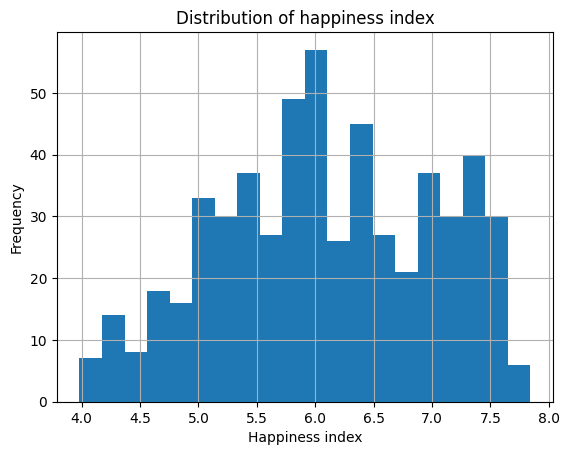

In [54]:
eda_df["happiness_index"].hist(bins=20)

plt.title("Distribution of happiness index")
plt.xlabel("Happiness index")
plt.ylabel("Frequency")

plt.show()

The happiness distribution appears relatively concentrated and approximately unimodal, with most observations clustered around values between roughly 5 and 7.

The distribution does not show extreme outliers or strong skewness within the observed range. This suggests that reported wellbeing is relatively centred within the sample, even though meaningful cross-country variation still exists.

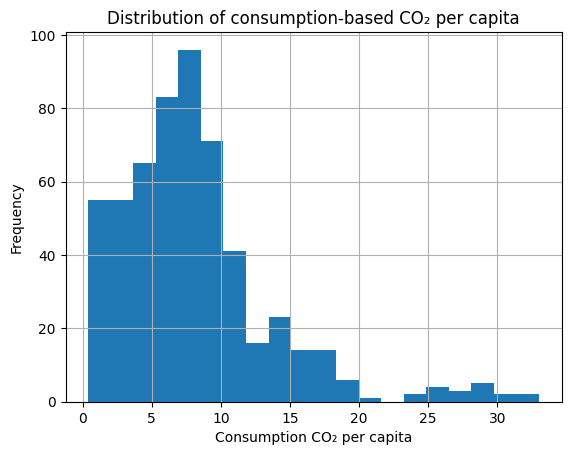

In [55]:
eda_df["consumption_co2_per_capita"].hist(bins=20)

plt.title("Distribution of consumption-based CO₂ per capita")
plt.xlabel("Consumption CO₂ per capita")
plt.ylabel("Frequency")

plt.show()

The distribution of consumption-based CO₂ emissions per capita is positively skewed.

Most observations are concentrated at lower-to-middle emission levels, while a smaller number of country-years extend toward substantially higher consumption-based emissions. The distribution therefore includes a long upper tail rather than being approximately symmetric.

This pattern suggests that very high consumption-based emissions are concentrated within a relatively limited subset of country-years, while most observations remain at comparatively lower levels of consumption-related carbon pressure.

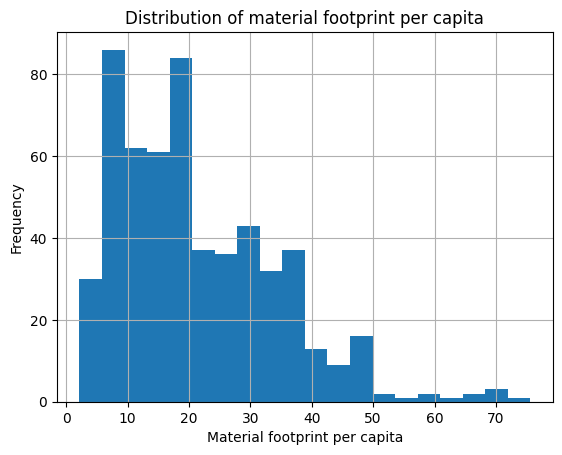

In [56]:
eda_df["material_footprint_per_capita"].hist(bins=20)

plt.title("Distribution of material footprint per capita")
plt.xlabel("Material footprint per capita")
plt.ylabel("Frequency")

plt.show()

The distribution of material footprint per capita is also positively skewed, though the spread across intermediate values appears broader than for consumption-based CO₂ emissions.

Most observations are concentrated at lower-to-middle material-footprint levels, while a smaller number of country-years extend toward substantially higher levels of material use. The distribution again includes a noticeable upper tail rather than a symmetric pattern.

This suggests that very high levels of material-resource use are concentrated within a relatively limited subset of observations, while most country-years remain within lower or moderate material-footprint ranges.

### 6.5 Transition to the exploratory analysis

The dataset overview suggests substantial variation across countries in wellbeing, emissions, material footprint, and inequality.

The next sections move from general descriptive context to the central analytical focus of the project: the relationship between wellbeing and environmental/material pressure, and whether some countries appear comparatively more wellbeing-efficient than others.

## 7. Production-based vs consumption-based emissions

We now begin the focused exploratory analysis by comparing production-based and consumption-based CO₂ emissions.

This distinction is important because production-based emissions attribute emissions to the country where they are generated, while consumption-based emissions attribute emissions to the country whose consumption ultimately drives production.

Countries that import large quantities of goods may therefore appear less emission-intensive under production-based accounting than under consumption-based accounting.

This section explores how strongly the two measures differ across the dataset and whether some countries systematically consume more carbon-intensive goods than they produce domestically.

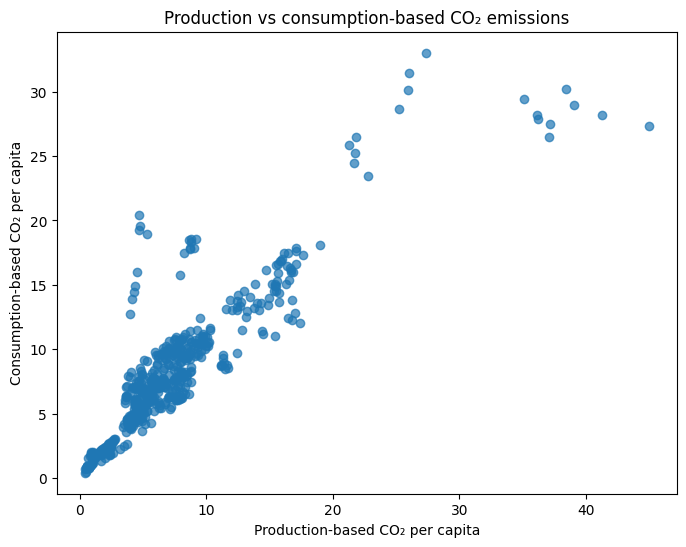

In [57]:
plt.figure(figsize=(8, 6))

plt.scatter(
    eda_df["co2_per_capita"],
    eda_df["consumption_co2_per_capita"],
    alpha=0.7,
)

plt.xlabel("Production-based CO₂ per capita")
plt.ylabel("Consumption-based CO₂ per capita")
plt.title("Production vs consumption-based CO₂ emissions")

plt.show()

We now colour the country-year scatterplot by human development group.

This helps assess whether the relationship between production-based and consumption-based emissions differs systematically across broad development categories.

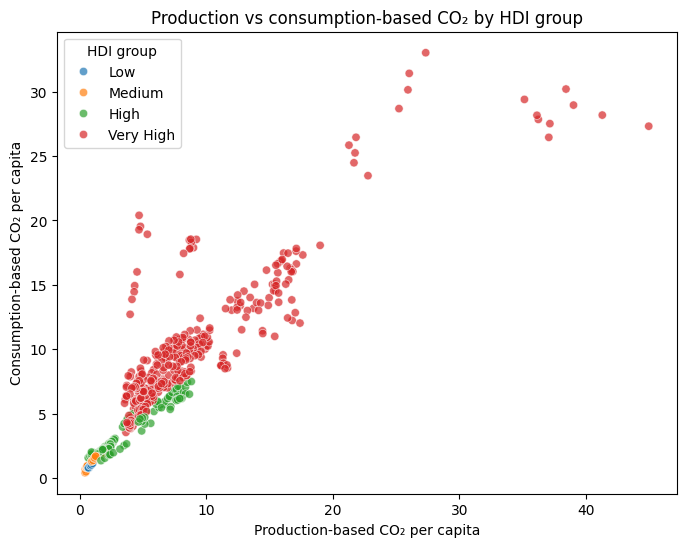

In [58]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=eda_df,
    x="co2_per_capita",
    y="consumption_co2_per_capita",
    hue="human_development_groups",
    alpha=0.7,
)

plt.xlabel("Production-based CO₂ per capita")
plt.ylabel("Consumption-based CO₂ per capita")
plt.title("Production vs consumption-based CO₂ by HDI group")

plt.legend(title="HDI group")

plt.show()

Colouring the country-year scatterplot by human development group reveals a clear structural pattern across development categories.

Very High HDI country-years occupy the broadest range of both production-based and consumption-based emissions, including nearly all of the highest-emission observations in the dataset.

By contrast, Low and Medium HDI country-years remain concentrated within comparatively low emissions ranges, while High HDI observations occupy an intermediate position between the lower and very high development groups.

The plot therefore suggests that higher levels of human development are frequently associated with higher carbon-intensive production and consumption patterns, although substantial variation still exists within the Very High HDI category itself.

At the same time, the broadly positive relationship between production-based and consumption-based emissions remains visible across all development categories.

The previous plot includes repeated yearly observations for each country.

We now aggregate emissions to the country level by taking average values across years. This reduces short-run yearly variation and helps highlight more persistent structural differences between countries.

Across countries on average, how closely aligned are production-based and consumption-based emissions?

In [59]:
country_avg_emissions = (
    eda_df.groupby("country")[
        [
            "co2_per_capita",
            "consumption_co2_per_capita",
        ]
    ]
    .mean()
    .reset_index()
)

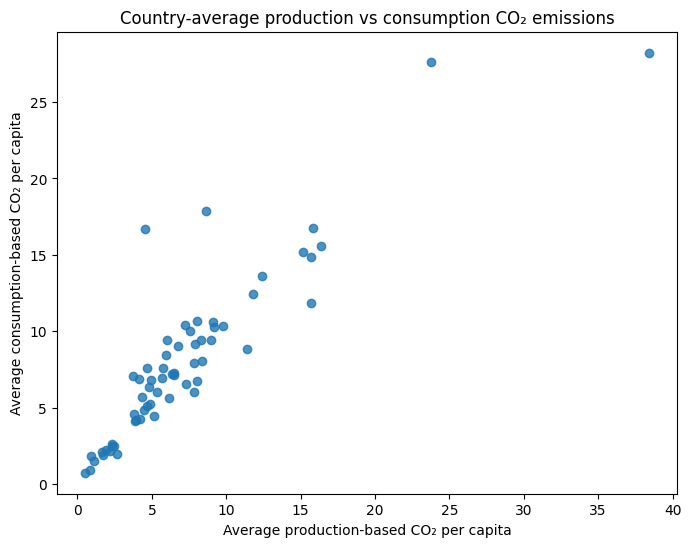

In [60]:
plt.figure(figsize=(8, 6))

plt.scatter(
    country_avg_emissions["co2_per_capita"],
    country_avg_emissions["consumption_co2_per_capita"],
    alpha=0.8,
)

plt.xlabel("Average production-based CO₂ per capita")
plt.ylabel("Average consumption-based CO₂ per capita")
plt.title("Country-average production vs consumption CO₂ emissions")

plt.show()

The country-average scatterplot reveals the relationship between production-based and consumption-based emissions more clearly at the structural country level.

The strong positive relationship remains visible, indicating that countries with higher average production-based emissions also tend to exhibit higher average consumption-based emissions.

At the same time, the country-level aggregation makes deviations from the general pattern easier to identify. Some countries appear systematically above the main concentration of points, suggesting comparatively higher consumption-driven emissions relative to domestic production. Others appear comparatively lower, indicating stronger production-oriented emission profiles.

Compared with the earlier country-year scatterplot, the averaged view reduces short-run yearly variation and highlights more persistent structural differences between countries.

This reinforces the analytical importance of distinguishing between production-based and consumption-based emissions when evaluating national environmental pressure.

We now repeat the country-average scatterplot, colouring countries by human development group.

This helps check whether the relationship between production-based and consumption-based emissions differs across broad development categories, without introducing too many visual groups.

In [61]:
country_avg_emissions_hdi = (
    eda_df.groupby(
        [
            "country",
            "human_development_groups",
        ],
        observed=True,
    )[
        [
            "co2_per_capita",
            "consumption_co2_per_capita",
        ]
    ]
    .mean()
    .reset_index()
)

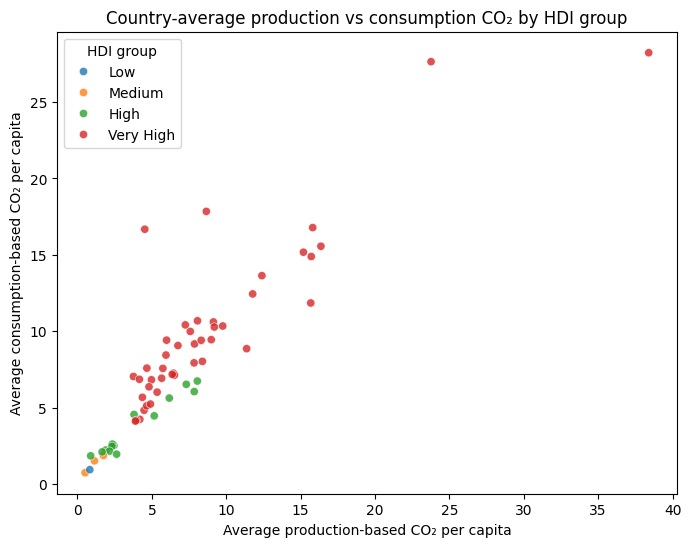

In [62]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=country_avg_emissions_hdi,
    x="co2_per_capita",
    y="consumption_co2_per_capita",
    hue="human_development_groups",
    alpha=0.8,
)

plt.xlabel("Average production-based CO₂ per capita")
plt.ylabel("Average consumption-based CO₂ per capita")
plt.title("Country-average production vs consumption CO₂ by HDI group")

plt.legend(title="HDI group")
plt.show()

Colouring the country-average scatterplot by human development group makes the structural relationship between development level and emissions patterns even clearer.

Countries in the Very High HDI category account for nearly all of the highest average production-based and consumption-based emission levels in the dataset. These countries also display the greatest spread in emissions profiles, suggesting substantial heterogeneity within the highest development category itself.

By contrast, Low and Medium HDI countries remain concentrated within comparatively low average emissions ranges, while High HDI countries occupy an intermediate position.

Compared with the country-year plot, the averaged view reduces short-run yearly variation and highlights more persistent country-level differences. The separation between development groups therefore appears to reflect broader structural characteristics rather than only temporary yearly fluctuations.

The plot suggests that higher levels of human development are frequently associated with higher long-run carbon-intensive production and consumption patterns, although the relationship is not perfectly uniform across countries.

We now compare the correlation between production-based and consumption-based emissions at both the country-year level and the country-average level.

The country-year correlation captures the overall relationship across all observations in the panel, while the country-average correlation focuses more directly on persistent structural differences between countries.

In [63]:
eda_df[
    [
        "co2_per_capita",
        "consumption_co2_per_capita",
    ]
].corr()

,co2_per_capita,consumption_co2_per_capita
co2_per_capita,1.000000,0.891245
consumption_co2_per_capita,0.891245,1.000000


In [64]:
country_avg_emissions[
    [
        "co2_per_capita",
        "consumption_co2_per_capita",
    ]
].corr()

,co2_per_capita,consumption_co2_per_capita
co2_per_capita,1.000000,0.895932
consumption_co2_per_capita,0.895932,1.000000


The correlation between production-based and consumption-based CO₂ emissions is strong and positive at both the country-year level (approximately 0.89) and the country-average level (approximately 0.90).

This indicates that countries with higher production-based emissions also tend to exhibit higher consumption-based emissions overall, both across yearly observations and at the longer-run structural country level.

The similarity between the two correlations suggests that the relationship between the two emissions measures is relatively stable rather than being driven mainly by short-run yearly fluctuations.

At the same time, the relationship remains imperfect. The remaining variation indicates that countries differ in the balance between domestically produced emissions and consumption-driven emissions, likely reflecting differences in trade structure, import dependence, and the international distribution of carbon-intensive production.

These results support the inclusion of both emissions measures in the later wellbeing-efficiency analysis rather than treating them as interchangeable indicators.

We now examine the distribution of the consumption-production CO₂ gap directly.

Positive values indicate country-years where consumption-based emissions exceed production-based emissions, while negative values indicate country-years where production-based emissions exceed consumption-based emissions.

In [65]:
eda_df["co2_consumption_production_gap"].describe()

count    558.000000
mean       0.831873
std        2.737232
min      -17.668000
25%        0.023000
50%        0.459000
75%        1.639750
max       15.711000
Name: co2_consumption_production_gap, dtype: float64

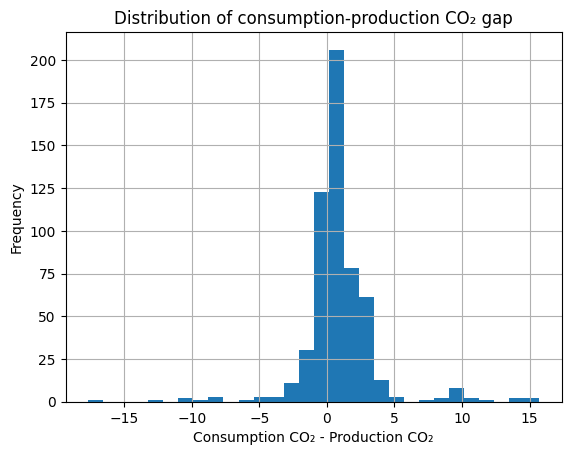

In [66]:
eda_df["co2_consumption_production_gap"].hist(bins=30)

plt.title("Distribution of consumption-production CO₂ gap")
plt.xlabel("Consumption CO₂ - Production CO₂")
plt.ylabel("Frequency")

plt.show()

The distribution of the consumption-production CO₂ gap is strongly concentrated around zero, indicating that for many country-years the two emissions measures remain relatively close.

However, the distribution is not perfectly centred or symmetric. The positive mean and median indicate that consumption-based emissions are generally somewhat higher than production-based emissions across the dataset.

The histogram also displays long tails on both sides of the distribution. Most observations cluster within a relatively narrow range, but a smaller number of country-years exhibit substantially positive or negative gaps.

Large positive values indicate country-years where consumption-based emissions substantially exceed production-based emissions, suggesting comparatively import-oriented or outsourced carbon consumption patterns.

Large negative values indicate country-years where production-based emissions exceed consumption-based emissions, suggesting comparatively production-oriented or export-intensive emissions profiles.

The presence of both positive and negative extremes suggests that production-based and consumption-based accounting can produce meaningfully different interpretations of national carbon pressure for some countries.

The previous histogram includes repeated yearly observations for each country.

We now examine the average consumption-production gap at the country level. This helps identify more persistent structural differences between countries rather than short-run yearly fluctuations.

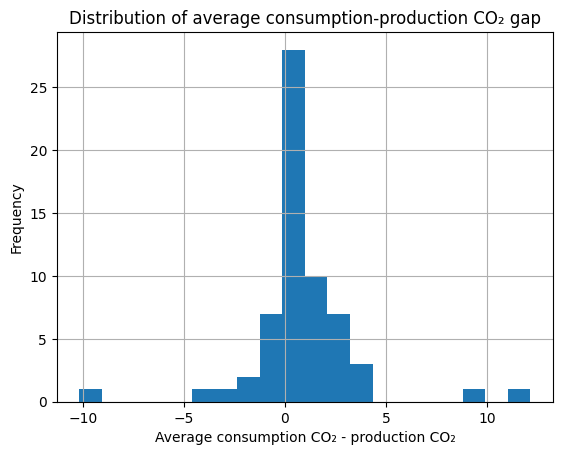

In [67]:
country_avg_gap = (
    eda_df.groupby("country")[
        "co2_consumption_production_gap"
    ]
    .mean()
    .reset_index()
)

country_avg_gap[
    "co2_consumption_production_gap"
].hist(bins=20)

plt.title("Distribution of average consumption-production CO₂ gap")
plt.xlabel("Average consumption CO₂ - production CO₂")
plt.ylabel("Frequency")

plt.show()

The distribution of the average consumption-production CO₂ gap is more concentrated than the country-year distribution, suggesting that some of the wider variation observed previously reflects short-run yearly fluctuations.

Most countries cluster relatively close to zero, indicating that production-based and consumption-based emissions remain broadly similar on average for many countries.

At the same time, the distribution still displays both positive and negative tails. This suggests that some countries exhibit persistent structural differences between domestically produced emissions and consumption-driven emissions.

Countries with strongly positive average gaps are likely to consume substantially more carbon-intensive goods than they produce domestically, while strongly negative average gaps suggest comparatively production-oriented or export-intensive emissions profiles.

The country-level aggregation therefore highlights more stable structural differences in carbon accounting patterns across countries.

Who are these extreme observations?

In [68]:
country_avg_gap.sort_values(
    "co2_consumption_production_gap",
    ascending=False,
).head(10)

,country,co2_consumption_production_gap
54,Switzerland,12.151000
5,Belgium,9.182444
58,United Arab Emirates,3.870444
15,Denmark,3.428778
31,Latvia,3.282000
27,Israel,3.169778
32,Lithuania,2.926111
53,Sweden,2.698667
19,Finland,2.620111
59,United Kingdom,2.495556


The countries with the largest positive average consumption-production gaps are predominantly high-income and highly developed economies.

Switzerland stands out as a particularly extreme case, exhibiting a substantially larger average consumption-based emissions profile relative to its domestic production-based emissions. Belgium also displays a notably large positive gap.

Several Northern and Western European countries appear among the largest positive-gap observations, including Denmark, Sweden, Finland, and the United Kingdom.

These patterns are broadly consistent with economies that consume substantial quantities of imported goods and whose consumption may therefore rely partly on carbon-intensive production occurring abroad.

The results suggest that production-based accounting alone may understate the carbon pressure associated with consumption patterns in some highly developed and trade-integrated economies.

In [69]:
country_avg_gap.sort_values(
    "co2_consumption_production_gap",
    ascending=True,
).head(10)

,country,co2_consumption_production_gap
44,Qatar,-10.173667
30,Kazakhstan,-3.827889
46,Russia,-2.507222
49,South Africa,-1.792333
25,Iran,-1.310667
33,Luxembourg,-0.823222
1,Australia,-0.799000
10,China,-0.782222
57,Ukraine,-0.688556
61,Vietnam,-0.667222


The countries with the largest negative average consumption-production gaps display a different structural profile.

Qatar stands out as the most extreme negative-gap country in the dataset, indicating substantially higher production-based emissions relative to domestic consumption-based emissions. Kazakhstan and Russia also exhibit strongly negative average gaps.

Several of these countries are major energy producers or resource-exporting economies, where large amounts of carbon-intensive production are associated with exports rather than domestic consumption alone.

Other countries with moderately negative gaps, including China and Vietnam, may reflect comparatively production-oriented economic structures linked to manufacturing and export activity.

These patterns highlight how production-based emissions can substantially exceed consumption-based emissions in export-intensive or resource-producing economies.

Taken together with the earlier positive-gap countries, the results suggest that the distinction between production-based and consumption-based accounting captures meaningful structural differences in how countries participate in the global economy and the international distribution of carbon-intensive production.

## 8. Wellbeing and consumption-based emissions efficiency

We now move to the central analytical focus of the project: the relationship between wellbeing and environmental pressure.

This section focuses specifically on consumption-based CO₂ emissions, since consumption-based accounting may better capture the carbon pressure associated with the lifestyles and consumption patterns experienced within countries.

We begin by examining the direct relationship between happiness and consumption-based emissions before turning to the engineered wellbeing-efficiency indicators.

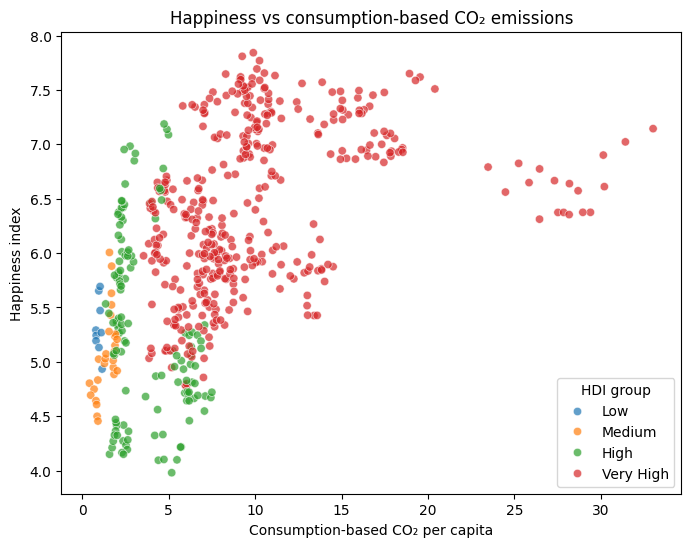

In [70]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=eda_df,
    x="consumption_co2_per_capita",
    y="happiness_index",
    hue="human_development_groups",
    alpha=0.7,
)

plt.xlabel("Consumption-based CO₂ per capita")
plt.ylabel("Happiness index")
plt.title("Happiness vs consumption-based CO₂ emissions")

plt.legend(title="HDI group")

plt.show()

The relationship between happiness and consumption-based CO₂ emissions appears positive overall, but not strictly linear.

Higher happiness levels are concentrated primarily within the Very High HDI group, which also occupies much of the higher-emissions range. Lower development groups remain concentrated within comparatively lower emissions and lower happiness ranges.

At the same time, the relationship does not appear proportional across the full emissions range. Several country-years achieve relatively high happiness at moderate consumption-based emissions levels, while some of the highest-emission observations do not exhibit correspondingly higher happiness scores.

This suggests that higher emissions and consumption levels may be associated with higher wellbeing up to a point, but that very high carbon-intensive consumption does not necessarily correspond to proportionally higher reported happiness.

The dispersion within the Very High HDI group is particularly important for the later efficiency analysis, because it suggests that countries with similar wellbeing outcomes may differ substantially in their associated consumption-based emissions.

The scatterplot suggests that much of the apparent positive relationship may reflect differences between development groups rather than a strongly linear relationship within groups themselves.

To investigate this more clearly, we add fitted regression lines to examine the overall direction of association and whether the relationship differs across development categories.

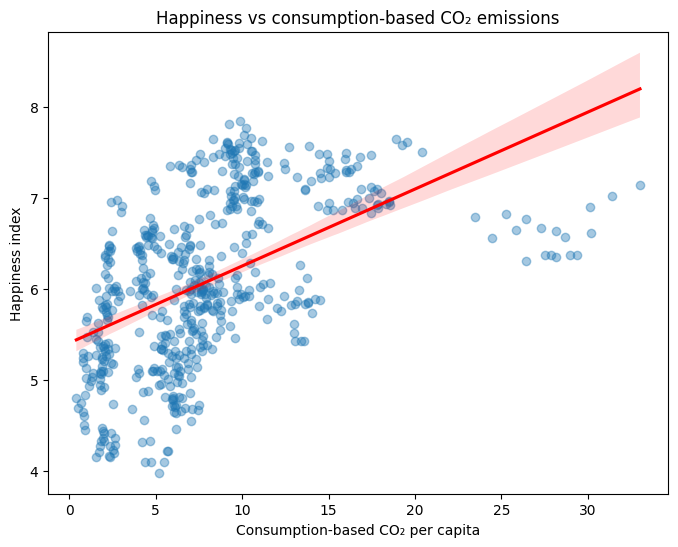

In [71]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=eda_df,
    x="consumption_co2_per_capita",
    y="happiness_index",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"},
)

plt.xlabel("Consumption-based CO₂ per capita")
plt.ylabel("Happiness index")
plt.title("Happiness vs consumption-based CO₂ emissions")

plt.show()

The earlier scatterplots suggest that much of the observed relationship between happiness and consumption-based emissions may reflect persistent differences between countries and development groups rather than within-country relationships over time.

To investigate this more directly, we now remove country-specific average levels from both variables. This produces a fixed-effects style visualisation that focuses on within-country variation over time rather than cross-country differences.

In [72]:
fe_df = eda_df.copy()

fe_df["happiness_within_country"] = (
    fe_df["happiness_index"]
    - fe_df.groupby("country")["happiness_index"].transform("mean")
)

fe_df["consumption_co2_within_country"] = (
    fe_df["consumption_co2_per_capita"]
    - fe_df.groupby("country")["consumption_co2_per_capita"].transform("mean")
)

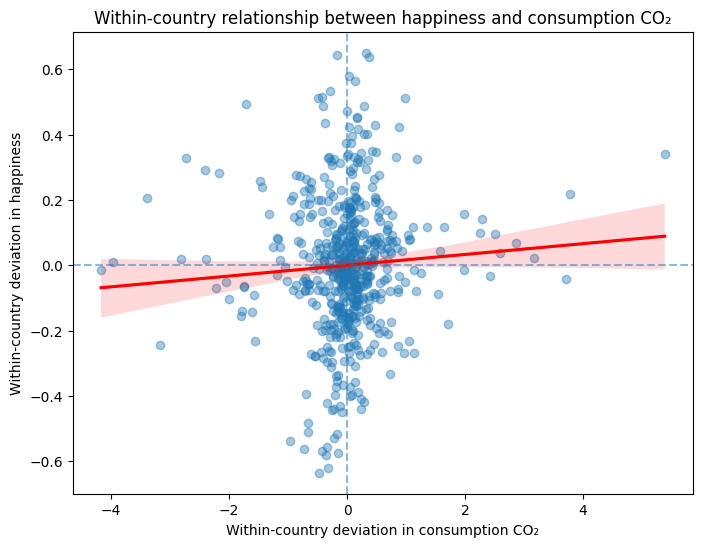

In [73]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=fe_df,
    x="consumption_co2_within_country",
    y="happiness_within_country",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"},
)

plt.xlabel("Within-country deviation in consumption CO₂")
plt.ylabel("Within-country deviation in happiness")
plt.title("Within-country relationship between happiness and consumption CO₂")

plt.axhline(0, linestyle="--", alpha=0.5)
plt.axvline(0, linestyle="--", alpha=0.5)

plt.show()

The within-country fixed-effects style plot presents a substantially weaker relationship between happiness and consumption-based CO₂ emissions than the earlier pooled scatterplots.

After removing country-specific average levels, the fitted relationship becomes only slightly positive, while the observations remain widely dispersed around the trend line.

This suggests that much of the stronger relationship observed previously may reflect persistent structural differences between countries — such as development level, institutional characteristics, or long-run consumption patterns — rather than strong within-country changes over time.

In other words, countries with higher average consumption-based emissions often also exhibit higher average happiness levels, but increases or decreases in emissions within a given country over time do not appear to correspond strongly to proportional changes in reported happiness.

This distinction is important for interpreting the later wellbeing-efficiency indicators, because it suggests that cross-country differences in wellbeing and environmental pressure may be driven more by structural development patterns than by short-run within-country dynamics alone.

We now turn to the engineered wellbeing-efficiency feature `happiness_per_consumption_co2`.

This feature measures reported happiness relative to consumption-based CO₂ emissions per capita. Higher values indicate country-years that achieve comparatively higher happiness levels for a given level of consumption-based carbon pressure.

The feature should not be interpreted as a causal or fully normative efficiency measure. Instead, it serves as an exploratory comparative indicator that helps identify countries appearing to achieve relatively high wellbeing with comparatively lower consumption-based emissions.

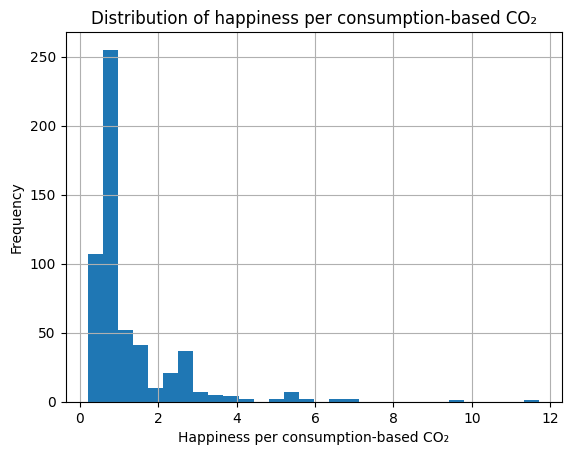

In [74]:
eda_df["happiness_per_consumption_co2"].hist(bins=30)

plt.title("Distribution of happiness per consumption-based CO₂")
plt.xlabel("Happiness per consumption-based CO₂")
plt.ylabel("Frequency")

plt.show()

The distribution of `happiness_per_consumption_co2` is strongly positively skewed.

Most observations cluster within relatively low-to-moderate values of the indicator, while a smaller number of country-years extend into a long upper tail.

This pattern suggests that a limited number of observations achieve comparatively high happiness levels relative to their consumption-based emissions. However, the strong skewness also indicates that the ratio can become sensitive when emissions levels are relatively low.

For this reason, the indicator should be interpreted cautiously as a comparative exploratory measure rather than a definitive measure of sustainability or wellbeing efficiency.

At the same time, the distribution suggests meaningful variation across country-years in the apparent relationship between wellbeing outcomes and consumption-based carbon pressure.

In [75]:
country_avg_efficiency = (
    eda_df.groupby("country")[
        [
            "happiness_index",
            "consumption_co2_per_capita",
            "happiness_per_consumption_co2",
        ]
    ]
    .mean()
    .reset_index()
)

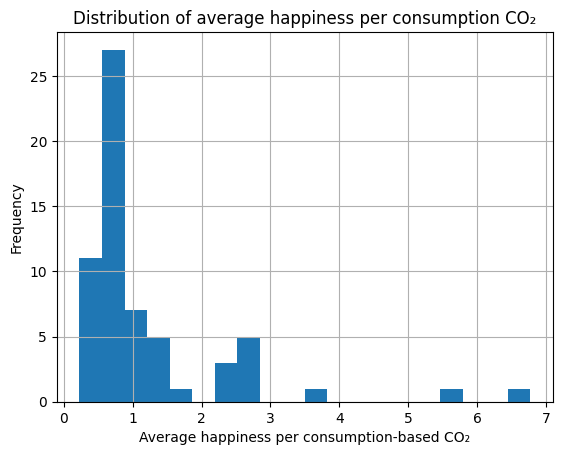

In [76]:
country_avg_efficiency[
    "happiness_per_consumption_co2"
].hist(bins=20)

plt.title("Distribution of average happiness per consumption CO₂")
plt.xlabel("Average happiness per consumption-based CO₂")
plt.ylabel("Frequency")

plt.show()

The country-average distribution of `happiness_per_consumption_co2` remains positively skewed, but the distribution becomes more stable and concentrated after averaging across years.

Compared with the earlier country-year distribution, the extreme upper tail is substantially reduced. This suggests that some of the most extreme observations in the full panel reflect short-run yearly fluctuations or denominator sensitivity rather than persistent structural country differences.

Most countries cluster within a relatively moderate range of average wellbeing-efficiency values, while a smaller number of countries exhibit substantially higher average happiness relative to their consumption-based emissions.

The country-level aggregation therefore provides a more stable basis for identifying countries that appear comparatively wellbeing-efficient over longer periods rather than only in isolated yearly observations.

To make the comparison more substantively meaningful, we now focus on countries that combine relatively high happiness with non-trivially low-to-moderate consumption-based emissions.

This helps avoid mechanically inflated ratio values driven primarily by extremely small emissions denominators.

In [77]:
median_happiness = country_avg_efficiency[
    "happiness_index"
].median()

filtered_efficiency = country_avg_efficiency[
    (
        country_avg_efficiency["happiness_index"]
        >= median_happiness
    )
    &
    (
        country_avg_efficiency[
            "consumption_co2_per_capita"
        ] >= 1
    )
]

The thresholds used here are pragmatic exploratory filters rather than theoretically fixed criteria. Their purpose is mainly to reduce extreme denominator sensitivity and focus attention on countries combining comparatively high wellbeing with non-trivially low-to-moderate emissions profiles.

In [78]:
filtered_efficiency.sort_values(
    "happiness_per_consumption_co2",
    ascending=False,
).head(15)

,country,happiness_index,consumption_co2_per_capita,happiness_per_consumption_co2
11,Colombia,6.304167,2.235222,2.826000
6,Brazil,6.640000,2.529222,2.654667
55,Thailand,6.244556,4.131000,1.515111
0,Argentina,6.370111,4.244556,1.508333
35,Mexico,6.737056,4.563222,1.479444
9,Chile,6.506944,4.838222,1.347444
53,Sweden,7.357111,6.863889,1.078111
51,Spain,6.366278,6.021889,1.061444
20,France,6.595944,6.830889,0.968444
47,Slovakia,6.122778,7.187000,0.853444


The filtered country rankings reveal several countries that appear to achieve comparatively high happiness levels relative to their consumption-based emissions.

Colombia and Brazil emerge as the highest-ranking countries within the filtered sample, combining moderately high average happiness levels with comparatively low-to-moderate consumption-based emissions. Several other Latin American countries, including Argentina, Mexico, and Chile, also appear near the top of the ranking.

This pattern is notable because these countries do not necessarily exhibit the very highest absolute happiness levels in the dataset. Instead, they appear comparatively favourable when wellbeing outcomes are considered relative to consumption-based carbon pressure.

Several Northern and Western European countries also rank relatively highly, including Sweden, Denmark, Norway, and the Netherlands. These countries combine very high happiness levels with emissions profiles that, while not low in absolute terms, appear comparatively moderate relative to their wellbeing outcomes.

The results therefore suggest that comparatively high wellbeing may be achievable under substantially different emissions profiles across countries.

At the same time, the rankings should be interpreted cautiously. The indicator is an exploratory ratio measure rather than a definitive measure of sustainability or social welfare efficiency, and the results remain sensitive to both denominator effects and broader structural differences between countries.

We now visualise the country-average relationship between happiness and consumption-based CO₂ emissions directly.

The plot combines average happiness, average consumption-based emissions, and development-group structure in a single figure. Median reference lines are added to help distinguish countries combining relatively high happiness with comparatively lower emissions.

In [79]:
country_avg_plot = (
    eda_df.groupby(
        [
            "country",
            "human_development_groups",
        ],
        observed=True,
    )[
        [
            "happiness_index",
            "consumption_co2_per_capita",
            "happiness_per_consumption_co2",
        ]
    ]
    .mean()
    .reset_index()
)

In [80]:
median_happiness = country_avg_plot["happiness_index"].median()
median_consumption = country_avg_plot[
    "consumption_co2_per_capita"
].median()

In [81]:
top_efficiency_countries = (
    filtered_efficiency.sort_values(
        "happiness_per_consumption_co2",
        ascending=False,
    )
    .head(10)["country"]
    .tolist()
)

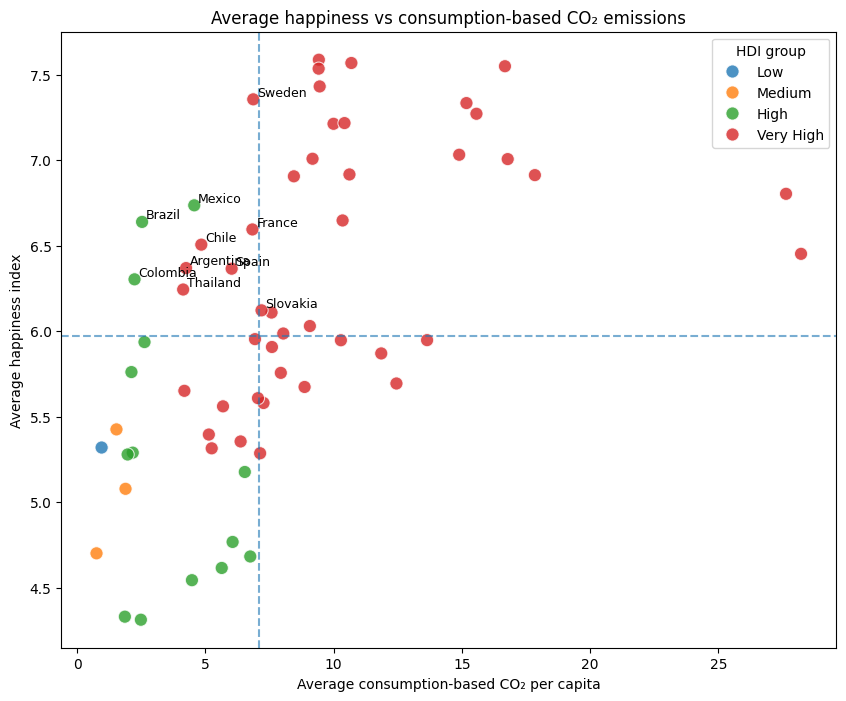

In [82]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=country_avg_plot,
    x="consumption_co2_per_capita",
    y="happiness_index",
    hue="human_development_groups",
    s=90,
    alpha=0.8,
)

plt.axhline(
    median_happiness,
    linestyle="--",
    alpha=0.6,
)

plt.axvline(
    median_consumption,
    linestyle="--",
    alpha=0.6,
)

for _, row in country_avg_plot.iterrows():
    if row["country"] in top_efficiency_countries:
        plt.text(
            row["consumption_co2_per_capita"] + 0.15,
            row["happiness_index"] + 0.02,
            row["country"],
            fontsize=9,
        )

plt.xlabel("Average consumption-based CO₂ per capita")
plt.ylabel("Average happiness index")
plt.title(
    "Average happiness vs consumption-based CO₂ emissions"
)

plt.legend(title="HDI group")

plt.show()

The country-average scatterplot highlights several important patterns in the relationship between wellbeing and consumption-based emissions.

First, higher average happiness levels are generally associated with higher development categories, but not necessarily with proportionally higher emissions. Countries with broadly similar happiness outcomes often occupy substantially different positions along the emissions axis.

Second, several countries — including Colombia, Brazil, Mexico, and Chile — appear in the relatively desirable upper-left region of the plot, combining above-median happiness with comparatively low consumption-based emissions. This suggests that relatively high wellbeing outcomes may be achievable under substantially lower carbon-intensive consumption profiles than those observed in some very high-emission countries.

Third, the relationship between emissions and happiness appears to weaken considerably beyond moderate emissions levels. Several of the highest-emission countries do not exhibit correspondingly higher happiness scores than countries with substantially lower consumption-based emissions.

This suggests that higher emissions and material consumption may not translate into proportionally higher reported wellbeing beyond certain levels of development and consumption. In this sense, the plot provides visual evidence of a partial decoupling between wellbeing outcomes and carbon-intensive consumption at higher emissions levels.

At the same time, the results remain exploratory and descriptive rather than causal. Differences in institutional quality, social structures, inequality, public services, cultural factors, and historical development trajectories may all contribute to the observed cross-country patterns.

While CO₂ emissions here capture carbon pressure associated with energy use and consumption, material footprint captures broader resource extraction and material consumption associated with economic activity and lifestyles.

The two measures are related but conceptually distinct. Countries may therefore appear differently positioned when environmental pressure is evaluated through material use rather than carbon emissions alone.

## 9. Wellbeing and material footprint efficiency

We now extend the analysis from carbon emissions to material footprint.

While CO₂ emissions capture carbon pressure associated with energy use and production, material footprint captures broader resource extraction and material consumption associated with economic activity and lifestyles.

The two measures are related but conceptually distinct. Countries may therefore appear differently positioned when environmental pressure is evaluated through material use rather than carbon emissions alone.

As in the previous section, we begin by examining the direct relationship between happiness and material footprint before turning to the engineered wellbeing-efficiency indicators.

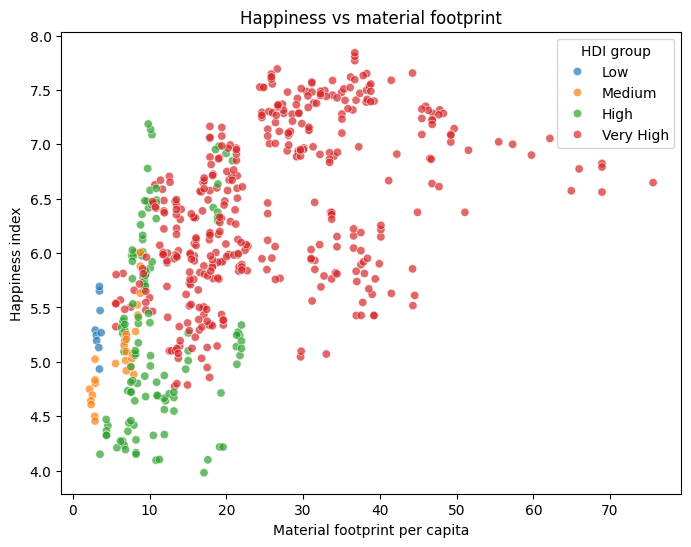

In [83]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=eda_df,
    x="material_footprint_per_capita",
    y="happiness_index",
    hue="human_development_groups",
    alpha=0.7,
)

plt.xlabel("Material footprint per capita")
plt.ylabel("Happiness index")
plt.title("Happiness vs material footprint")

plt.legend(title="HDI group")

plt.show()

The relationship between happiness and material footprint appears broadly positive, but again not strictly linear.

Higher happiness levels remain concentrated primarily within the Very High HDI group, while lower development categories are generally associated with both lower happiness and lower material-footprint levels.

At the same time, the plot suggests substantial dispersion in material footprint among countries exhibiting relatively similar happiness outcomes. Several countries achieve comparatively high happiness at moderate material-footprint levels, while some very high material-footprint observations do not correspond to substantially higher happiness scores.

The spread in material footprint also appears wider than in the earlier consumption-based CO₂ analysis. In particular, several countries exhibit extremely high material-footprint levels without clearly higher wellbeing outcomes relative to countries with substantially lower material consumption.

This again suggests the possibility of partial decoupling between wellbeing and environmental/resource pressure beyond moderate levels of material consumption.

As in the previous section, we now examine the within-country relationship after removing country-specific average levels from both variables.

This helps distinguish persistent structural differences between countries from within-country changes over time.

In [84]:
fe_df["material_footprint_within_country"] = (
    fe_df["material_footprint_per_capita"]
    - fe_df.groupby("country")[
        "material_footprint_per_capita"
    ].transform("mean")
)

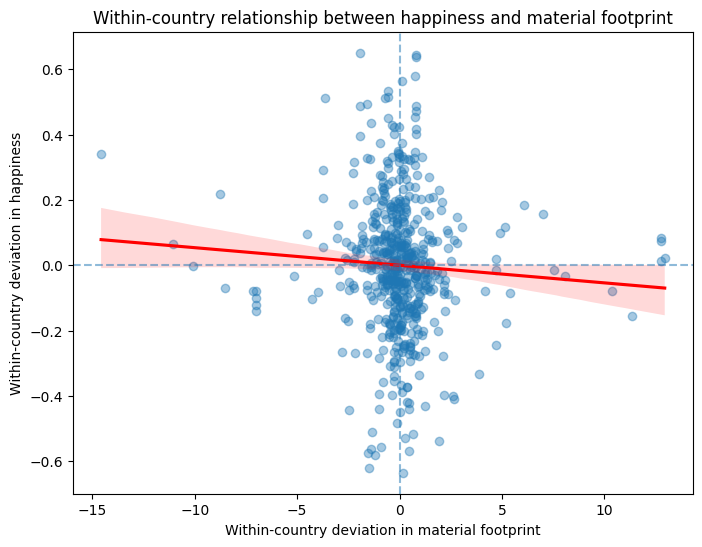

In [85]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=fe_df,
    x="material_footprint_within_country",
    y="happiness_within_country",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"},
)

plt.xlabel("Within-country deviation in material footprint")
plt.ylabel("Within-country deviation in happiness")
plt.title(
    "Within-country relationship between happiness and material footprint"
)

plt.axhline(0, linestyle="--", alpha=0.5)
plt.axvline(0, linestyle="--", alpha=0.5)

plt.show()

The within-country relationship between happiness and material footprint appears extremely weak and slightly negative after removing country-specific average levels.

Compared with the earlier pooled scatterplot, the fitted relationship largely disappears once persistent structural country differences are removed. The observations remain widely dispersed around the trend line, with little evidence of a strong linear within-country association.

This suggests that countries with higher average material footprints often also exhibit higher average happiness levels, but increases in material consumption within countries over time do not appear to correspond systematically to higher reported wellbeing.

The contrast between the pooled and within-country relationships therefore reinforces the idea that much of the observed association reflects broader structural development differences between countries rather than strong short-run wellbeing gains from increasing material consumption itself.

The slightly negative fitted trend may also suggest diminishing or saturated wellbeing returns to additional material consumption beyond moderate levels of development and resource use, although the relationship remains weak and exploratory rather than strongly causal.

We now examine the engineered wellbeing-efficiency feature `happiness_per_material_footprint`.

This feature measures reported happiness relative to material footprint per capita. Higher values indicate country-years that achieve comparatively higher happiness levels for a given level of material-resource use.

As in the previous section, the indicator should be interpreted as an exploratory comparative measure rather than a definitive or causal measure of sustainability efficiency.

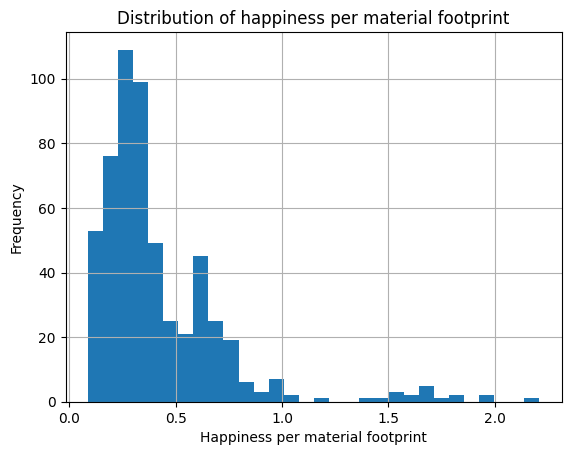

In [86]:
eda_df["happiness_per_material_footprint"].hist(bins=30)

plt.title("Distribution of happiness per material footprint")
plt.xlabel("Happiness per material footprint")
plt.ylabel("Frequency")

plt.show()

The distribution of `happiness_per_material_footprint` is positively skewed, though less extremely than the earlier consumption-based CO₂ efficiency indicator.

Most observations cluster within relatively low-to-moderate values, while a smaller number of country-years extend into a higher-efficiency upper tail.

Compared with the CO₂-based ratio, the distribution appears more concentrated and less dominated by extreme observations. This suggests that the material-footprint efficiency indicator may be somewhat less sensitive to very small denominator values and may provide a more stable comparative measure across countries.

At the same time, the distribution still indicates substantial variation in how countries combine wellbeing outcomes with material-resource use.

The presence of higher-efficiency observations suggests that some countries appear able to achieve comparatively high happiness levels under substantially lower material-consumption profiles than others.

In [87]:
country_avg_material_efficiency = (
    eda_df.groupby("country")[
        [
            "happiness_index",
            "material_footprint_per_capita",
            "happiness_per_material_footprint",
        ]
    ]
    .mean()
    .reset_index()
)

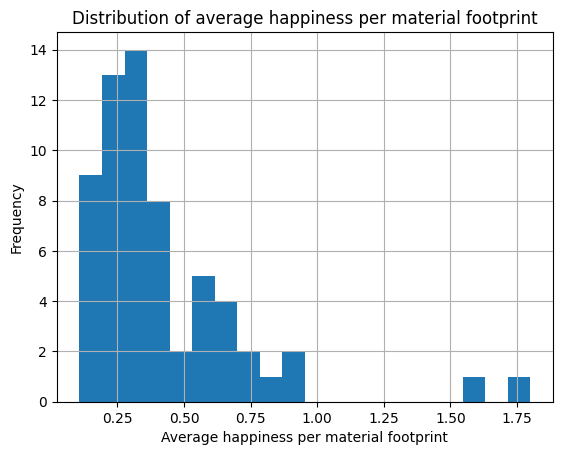

In [88]:
country_avg_material_efficiency[
    "happiness_per_material_footprint"
].hist(bins=20)

plt.title(
    "Distribution of average happiness per material footprint"
)

plt.xlabel("Average happiness per material footprint")
plt.ylabel("Frequency")

plt.show()

The country-average distribution of `happiness_per_material_footprint` becomes substantially more concentrated after averaging across years.

Compared with the country-year distribution, the extreme upper tail is reduced considerably, suggesting that some of the most extreme yearly observations reflect short-run fluctuations rather than persistent structural country differences.

Most countries cluster within a moderate range of average wellbeing-efficiency values, while a smaller number of countries exhibit comparatively high happiness relative to their material footprint.

The distribution also appears somewhat more stable and less extreme than the earlier CO₂-based efficiency indicator. This may reflect the broader and less volatile nature of material-footprint measures relative to carbon-emissions indicators.

Overall, the country-level aggregation suggests meaningful cross-country variation in how wellbeing outcomes relate to long-run patterns of material-resource use.

In [89]:
median_happiness_material = (
    country_avg_material_efficiency[
        "happiness_index"
    ].median()
)

filtered_material_efficiency = (
    country_avg_material_efficiency[
        (
            country_avg_material_efficiency[
                "happiness_index"
            ]
            >= median_happiness_material
        )
        &
        (
            country_avg_material_efficiency[
                "material_footprint_per_capita"
            ]
            >= 5
        )
    ]
)

In [90]:
filtered_material_efficiency.sort_values(
    "happiness_per_material_footprint",
    ascending=False,
).head(15)

,country,happiness_index,material_footprint_per_capita,happiness_per_material_footprint
11,Colombia,6.304167,9.353333,0.674889
35,Mexico,6.737056,10.384444,0.651000
55,Thailand,6.244556,11.213333,0.558889
9,Chile,6.506944,12.532222,0.523444
28,Italy,6.109722,12.797778,0.479889
51,Spain,6.366278,14.613333,0.438111
0,Argentina,6.370111,16.796667,0.379556
59,United Kingdom,6.906778,18.216667,0.379333
20,France,6.595944,18.916667,0.350889
6,Brazil,6.640000,19.125556,0.347333


The material-footprint efficiency rankings reveal several countries that appear to achieve comparatively high happiness levels relative to long-run material-resource use.

Colombia and Mexico emerge as the highest-ranking countries within the filtered sample, while Thailand and Chile also perform strongly. Several Southern and Western European countries, including Italy, Spain, France, and the United Kingdom, also appear relatively highly ranked.

Compared with the earlier CO₂-based efficiency rankings, the material-footprint rankings display both similarities and important differences. Some countries remain consistently prominent across both environmental-pressure measures, suggesting comparatively stable wellbeing-efficiency patterns across multiple dimensions of environmental impact.

At the same time, several countries change position noticeably between the two rankings. This suggests that carbon emissions and material-resource use capture partly distinct aspects of environmental pressure and may reflect different economic and consumption structures across countries.

The results again suggest that comparatively high wellbeing outcomes may be achievable under substantially different levels of material-resource use across countries.

However, the indicator remains exploratory rather than definitive. The rankings are sensitive to denominator effects, structural economic differences, and broader institutional and developmental factors that are not directly captured by the ratio measure itself.

We now visualise the country-average relationship between happiness and material footprint directly.

As in the earlier CO₂ analysis, the plot combines average happiness, average material footprint, and development-group structure in a single figure. Median reference lines help distinguish countries combining relatively high happiness with comparatively lower material-resource use.

In [91]:
country_avg_material_plot = (
    eda_df.groupby(
        [
            "country",
            "human_development_groups",
        ],
        observed=True,
    )[
        [
            "happiness_index",
            "material_footprint_per_capita",
            "happiness_per_material_footprint",
        ]
    ]
    .mean()
    .reset_index()
)

In [92]:
median_happiness_material_plot = (
    country_avg_material_plot["happiness_index"]
    .median()
)

median_material = (
    country_avg_material_plot[
        "material_footprint_per_capita"
    ]
    .median()
)

In [93]:
top_material_efficiency_countries = (
    filtered_material_efficiency.sort_values(
        "happiness_per_material_footprint",
        ascending=False,
    )
    .head(10)["country"]
    .tolist()
)

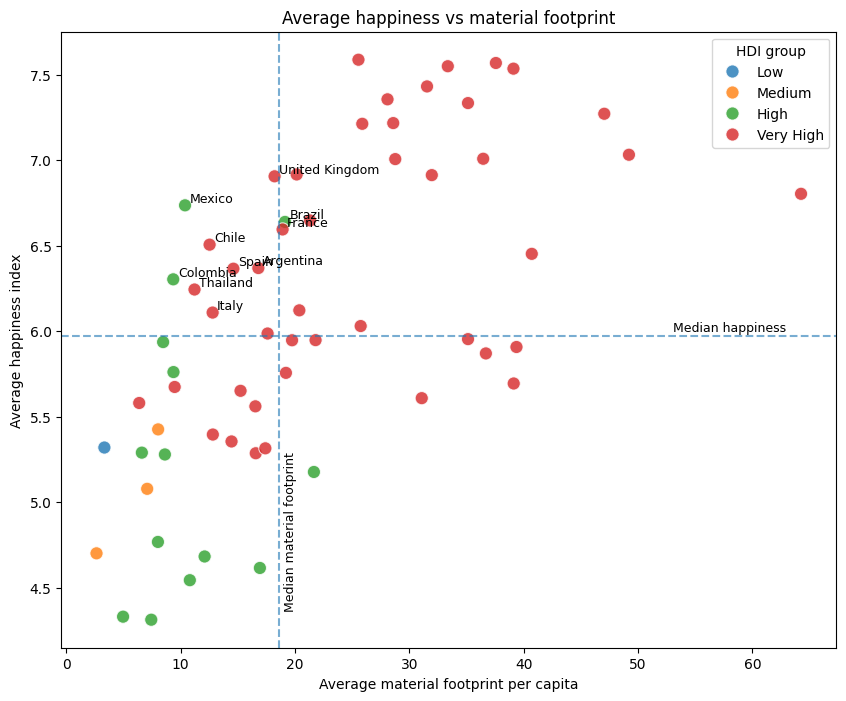

In [94]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=country_avg_material_plot,
    x="material_footprint_per_capita",
    y="happiness_index",
    hue="human_development_groups",
    s=90,
    alpha=0.8,
)

plt.axhline(
    median_happiness_material_plot,
    linestyle="--",
    alpha=0.6,
)

plt.text(
    country_avg_material_plot[
        "material_footprint_per_capita"
    ].max() * 0.98,
    median_happiness_material_plot + 0.03,
    "Median happiness",
    ha="right",
    fontsize=9,
)

plt.axvline(
    median_material,
    linestyle="--",
    alpha=0.6,
)

plt.text(
    median_material + 0.5,
    country_avg_material_plot[
        "happiness_index"
    ].min() + 0.05,
    "Median material footprint",
    rotation=90,
    va="bottom",
    fontsize=9,
)

for _, row in country_avg_material_plot.iterrows():
    if row["country"] in top_material_efficiency_countries:
        plt.text(
            row["material_footprint_per_capita"] + 0.4,
            row["happiness_index"] + 0.02,
            row["country"],
            fontsize=9,
        )

plt.xlabel("Average material footprint per capita")
plt.ylabel("Average happiness index")

plt.title(
    "Average happiness vs material footprint"
)

plt.legend(title="HDI group")

plt.show()

The country-average material-footprint plot reinforces several patterns already observed in the earlier CO₂ analysis.

First, countries with broadly similar happiness outcomes often exhibit substantially different levels of material-resource use. Several countries combining above-median happiness with comparatively moderate material footprints appear in the upper-left region of the figure, including Colombia, Mexico, Chile, Thailand, and several European countries.

Second, the relationship between material footprint and happiness appears to weaken considerably at higher levels of material consumption. Countries with extremely large material footprints do not appear proportionally happier than countries with substantially lower levels of material-resource use.

This pattern suggests a partial decoupling between wellbeing outcomes and material-resource consumption beyond moderate levels of development and consumption.

Compared with the earlier CO₂ analysis, the decoupling pattern may appear even stronger for material footprint. The figure suggests that very high levels of material consumption are not systematically associated with correspondingly higher wellbeing outcomes across countries.

At the same time, the plot continues to show the importance of broader structural development differences. Very High HDI countries dominate the upper range of happiness outcomes overall, even though they differ substantially in their associated levels of material-resource use.

Taken together, the CO₂ and material-footprint analyses suggest that countries may achieve relatively high wellbeing outcomes under substantially different environmental and resource-use profiles, particularly once very high levels of consumption are reached.

## 10. Inequality-adjusted wellbeing

We now examine the inequality-adjusted happiness indicator.

The feature adjusts reported happiness using the Gini index, with the aim of accounting for differences in income inequality across countries. The adjustment reflects the idea that similar average happiness outcomes may be experienced differently depending on how unequally economic resources are distributed.

The indicator therefore provides an exploratory measure of wellbeing that incorporates both average happiness and inequality conditions.

As with the earlier engineered indicators, the measure should be interpreted cautiously and comparatively rather than as a definitive welfare metric.

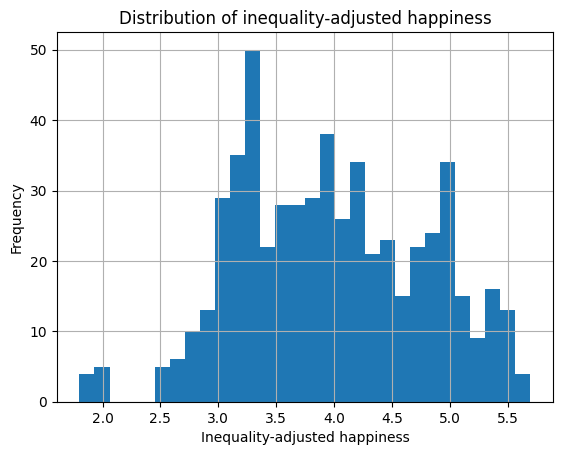

In [95]:
eda_df["inequality_adjusted_happiness"].hist(
    bins=30
)

plt.title(
    "Distribution of inequality-adjusted happiness"
)

plt.xlabel("Inequality-adjusted happiness")
plt.ylabel("Frequency")

plt.show()

The distribution of inequality-adjusted happiness remains broadly centred and approximately unimodal, though shifted downward relative to the original happiness distribution.

The adjustment compresses some of the higher wellbeing values and reduces the upper range of the distribution, reflecting the effect of incorporating inequality conditions into the wellbeing measure.

At the same time, substantial variation remains across country-years. Countries with similar average happiness levels may therefore differ meaningfully once inequality is taken into account.

The distribution suggests that accounting for inequality may alter comparative wellbeing assessments even when countries appear relatively similar in terms of unadjusted happiness alone.

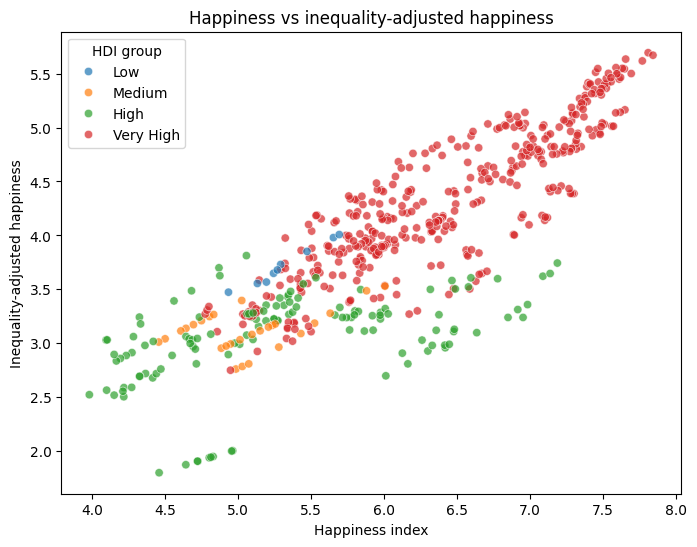

In [96]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=eda_df,
    x="happiness_index",
    y="inequality_adjusted_happiness",
    hue="human_development_groups",
    alpha=0.7,
)

plt.xlabel("Happiness index")
plt.ylabel("Inequality-adjusted happiness")

plt.title(
    "Happiness vs inequality-adjusted happiness"
)

plt.legend(title="HDI group")

plt.show()

The relationship between happiness and inequality-adjusted happiness remains strongly positive overall, indicating that countries with higher reported happiness also tend to exhibit higher inequality-adjusted wellbeing.

At the same time, the adjustment introduces substantial vertical dispersion around the general relationship. Countries with broadly similar happiness levels may differ noticeably once inequality conditions are taken into account.

This dispersion is particularly visible within the Very High HDI group, where some countries retain comparatively high inequality-adjusted wellbeing while others experience larger downward adjustments.

The figure therefore suggests that inequality meaningfully modifies comparative wellbeing outcomes even among countries with relatively similar average happiness levels.

At the same time, the adjustment does not completely overturn the broader wellbeing structure of the dataset. Higher development groups still tend to occupy the upper range of both happiness and inequality-adjusted happiness overall.

Which countries are most affected by the adjustment?

In [97]:
eda_df["inequality_adjustment_gap"] = (
    eda_df["happiness_index"]
    - eda_df["inequality_adjusted_happiness"]
)

In [98]:
country_avg_inequality = (
    eda_df.groupby("country")[
        [
            "happiness_index",
            "inequality_adjusted_happiness",
            "inequality_adjustment_gap",
            "gini_index",
        ]
    ]
    .mean()
    .reset_index()
)

In [99]:
country_avg_inequality.sort_values(
    "inequality_adjustment_gap",
    ascending=False,
).head(15)

,country,happiness_index,inequality_adjusted_happiness,inequality_adjustment_gap,gini_index
6,Brazil,6.640000,3.153889,3.486111,52.500000
11,Colombia,6.304167,2.975778,3.328389,52.811111
35,Mexico,6.737056,3.592000,3.145056,46.616667
9,Chile,6.506944,3.507222,2.999722,46.116667
60,United States,7.007500,4.125000,2.882500,41.133333
49,South Africa,4.767944,1.926111,2.841833,59.600000
27,Israel,7.218167,4.417111,2.801056,38.800000
16,Ecuador,5.937111,3.220556,2.716556,45.755556
0,Argentina,6.370111,3.690667,2.679444,42.083333
54,Switzerland,7.550722,5.054000,2.496722,33.066667


The inequality-adjustment rankings reveal substantial differences in how countries’ wellbeing outcomes appear once inequality conditions are incorporated.

Several countries experiencing the largest downward adjustments — including Brazil, Colombia, Mexico, and Chile — were previously among the strongest performers in the environmental wellbeing-efficiency analysis. These countries combine comparatively favourable happiness-to-environmental-pressure ratios with relatively high levels of income inequality.

As a result, their apparent wellbeing performance declines substantially once inequality is taken into account.

The results therefore suggest that environmental wellbeing-efficiency and distributional equality do not necessarily coincide. Countries may appear comparatively efficient in achieving wellbeing relative to environmental pressure while still exhibiting substantial internal inequality.

The table also shows that some highly developed countries, including the United States and Israel, experience relatively large inequality adjustments despite high average happiness levels.

At the same time, the adjustment does not simply reflect development level alone. Countries with comparatively similar happiness levels may experience substantially different downward adjustments depending on their inequality profiles.

Overall, the results suggest that incorporating inequality meaningfully changes comparative wellbeing assessments and provides a more multidimensional perspective on social outcomes than average happiness measures alone.

Taken together, the preceding analyses suggest that wellbeing, environmental pressure, and inequality interact in complex ways across countries.

Countries appearing comparatively wellbeing-efficient from an environmental perspective do not necessarily exhibit equally favourable distributional outcomes, while countries with high average happiness levels may differ substantially in both environmental pressure and inequality conditions.

The results therefore highlight the importance of considering multiple dimensions simultaneously when evaluating national wellbeing and sustainability patterns.

In [100]:
country_avg_adj_co2_plot = (
    eda_df.groupby(
        [
            "country",
            "human_development_groups",
        ],
        observed=True,
    )[
        [
            "inequality_adjusted_happiness",
            "consumption_co2_per_capita",
            "ineq_adj_happiness_per_consumption_co2",
        ]
    ]
    .mean()
    .reset_index()
)

median_adj_happiness_co2 = (
    country_avg_adj_co2_plot["inequality_adjusted_happiness"]
    .median()
)

median_consumption_co2 = (
    country_avg_adj_co2_plot["consumption_co2_per_capita"]
    .median()
)

top_adj_co2_countries = (
    country_avg_adj_co2_plot.sort_values(
        "ineq_adj_happiness_per_consumption_co2",
        ascending=False,
    )
    .head(10)["country"]
    .tolist()
)

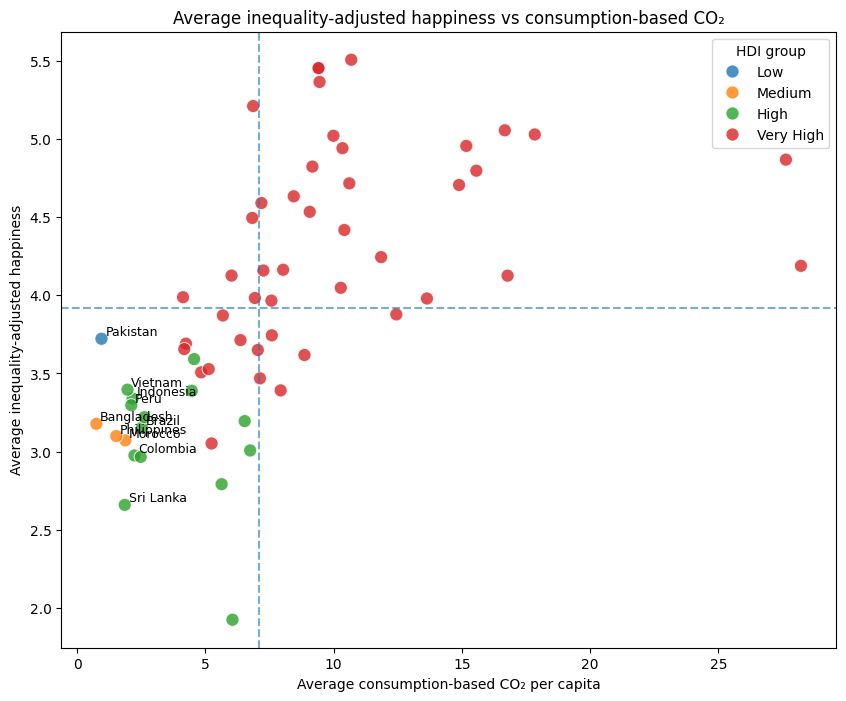

In [101]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=country_avg_adj_co2_plot,
    x="consumption_co2_per_capita",
    y="inequality_adjusted_happiness",
    hue="human_development_groups",
    s=90,
    alpha=0.8,
)

plt.axhline(
    median_adj_happiness_co2,
    linestyle="--",
    alpha=0.6,
)

plt.axvline(
    median_consumption_co2,
    linestyle="--",
    alpha=0.6,
)

for _, row in country_avg_adj_co2_plot.iterrows():
    if row["country"] in top_adj_co2_countries:
        plt.text(
            row["consumption_co2_per_capita"] + 0.15,
            row["inequality_adjusted_happiness"] + 0.02,
            row["country"],
            fontsize=9,
        )

plt.xlabel("Average consumption-based CO₂ per capita")
plt.ylabel("Average inequality-adjusted happiness")

plt.title(
    "Average inequality-adjusted happiness vs consumption-based CO₂"
)

plt.legend(title="HDI group")

plt.show()

In [102]:
country_avg_adj_material_plot = (
    eda_df.groupby(
        [
            "country",
            "human_development_groups",
        ],
        observed=True,
    )[
        [
            "inequality_adjusted_happiness",
            "material_footprint_per_capita",
            "ineq_adj_happiness_per_material_footprint",
        ]
    ]
    .mean()
    .reset_index()
)

median_adj_happiness_material = (
    country_avg_adj_material_plot[
        "inequality_adjusted_happiness"
    ].median()
)

median_material_footprint = (
    country_avg_adj_material_plot[
        "material_footprint_per_capita"
    ].median()
)

top_adj_material_countries = (
    country_avg_adj_material_plot.sort_values(
        "ineq_adj_happiness_per_material_footprint",
        ascending=False,
    )
    .head(10)["country"]
    .tolist()
)

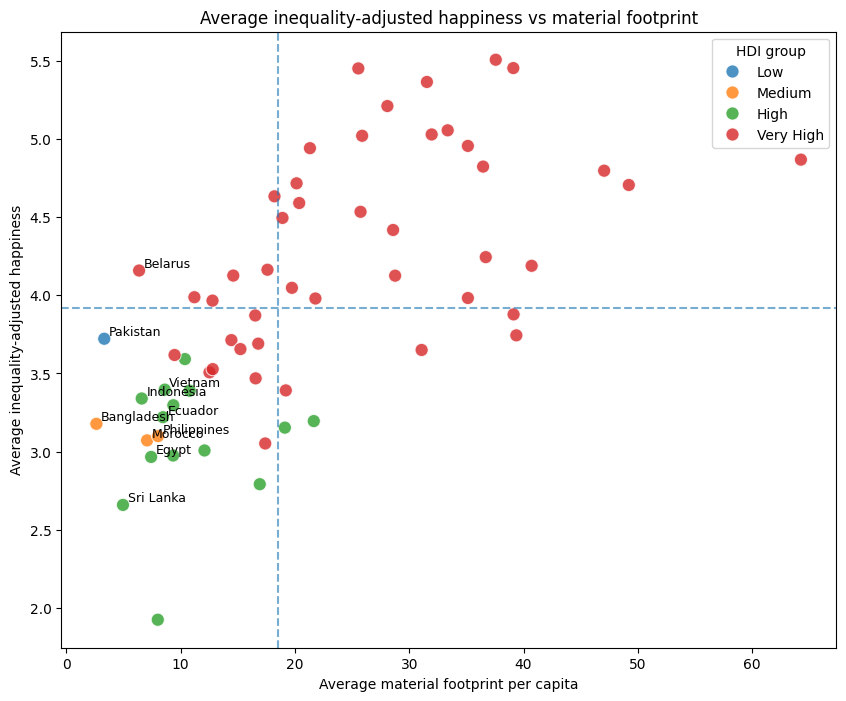

In [103]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=country_avg_adj_material_plot,
    x="material_footprint_per_capita",
    y="inequality_adjusted_happiness",
    hue="human_development_groups",
    s=90,
    alpha=0.8,
)

plt.axhline(
    median_adj_happiness_material,
    linestyle="--",
    alpha=0.6,
)

plt.axvline(
    median_material_footprint,
    linestyle="--",
    alpha=0.6,
)

for _, row in country_avg_adj_material_plot.iterrows():
    if row["country"] in top_adj_material_countries:
        plt.text(
            row["material_footprint_per_capita"] + 0.4,
            row["inequality_adjusted_happiness"] + 0.02,
            row["country"],
            fontsize=9,
        )

plt.xlabel("Average material footprint per capita")
plt.ylabel("Average inequality-adjusted happiness")

plt.title(
    "Average inequality-adjusted happiness vs material footprint"
)

plt.legend(title="HDI group")

plt.show()

Taken together, the inequality-adjusted analyses suggest that very few countries simultaneously combine:

- high wellbeing,
- comparatively low environmental pressure,
- and relatively equitable social outcomes.

Countries that appeared comparatively favourable from an environmental wellbeing-efficiency perspective often experience substantial downward adjustments once inequality is incorporated into the analysis.

The results therefore point less toward the existence of clear “successful” models and more toward persistent trade-offs and structural tensions between multiple social and environmental objectives.

In particular, the findings suggest that reducing environmental pressure alone does not guarantee cohesive or equitable wellbeing outcomes. At the same time, very high material consumption and emissions levels also do not appear to generate proportionally higher wellbeing outcomes.

The analysis therefore highlights the difficulty of simultaneously achieving environmental sustainability, high average wellbeing, and relatively equitable social conditions within existing development structures.

One possible interpretation of these patterns is that subjective wellbeing measures may partly reflect adaptation to prevailing social structures rather than purely objective living conditions.

Countries exhibiting relatively high happiness despite substantial inequality may reflect social contexts in which unequal outcomes are historically normalized, culturally expected, or institutionally embedded. In such settings, individuals may evaluate their wellbeing relative to local expectations, reference groups, or culturally accepted social hierarchies rather than according to absolute equality or material fairness alone.

Under this interpretation, subjective wellbeing may sometimes coexist with substantial structural inequality because individuals adapt psychologically and socially to persistent distributions of opportunity and status.

This does not imply that inequality improves wellbeing. Rather, it suggests that subjective wellbeing indicators may not fully capture tensions related to class divisions, unequal access to resources, social cohesion, or broader distributive justice.

The inequality-adjusted analyses in this project partly address this limitation by incorporating distributional conditions into the wellbeing framework, though important conceptual questions remain open.

Before constructing a combined environmental pressure index, we first inspect how the three environmental pressure variables relate to happiness at the country-average level.

This helps check whether production-based CO₂, consumption-based CO₂, and material footprint show broadly similar patterns, or whether combining them may obscure important differences.

In [104]:
country_env_avg = (
    eda_df.groupby("country")[
        [
            "happiness_index",
            "co2_per_capita",
            "consumption_co2_per_capita",
            "material_footprint_per_capita",
        ]
    ]
    .mean()
    .reset_index()
)

In [105]:
country_co2_long = country_env_avg.melt(
    id_vars=[
        "country",
        "happiness_index",
    ],
    value_vars=[
        "co2_per_capita",
        "consumption_co2_per_capita",
    ],
    var_name="co2_measure",
    value_name="co2_pressure",
)

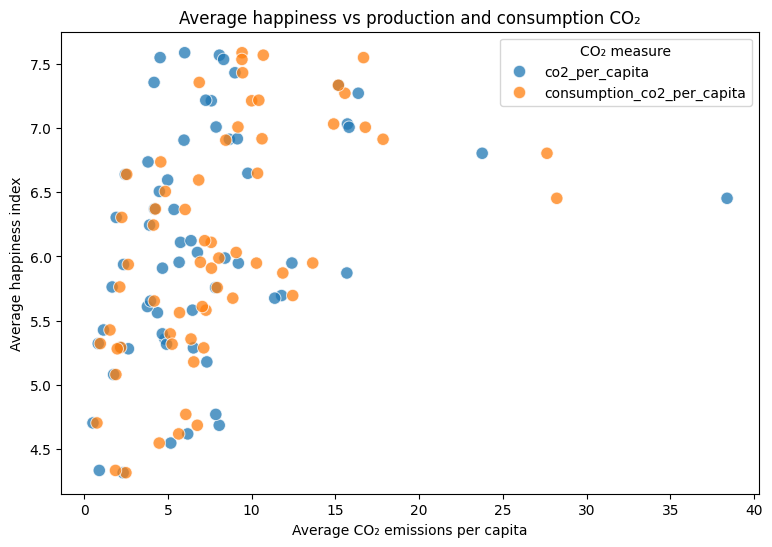

In [106]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=country_co2_long,
    x="co2_pressure",
    y="happiness_index",
    hue="co2_measure",
    alpha=0.75,
    s=80,
)

plt.xlabel("Average CO₂ emissions per capita")
plt.ylabel("Average happiness index")

plt.title(
    "Average happiness vs production and consumption CO₂"
)

plt.legend(title="CO₂ measure")

plt.show()

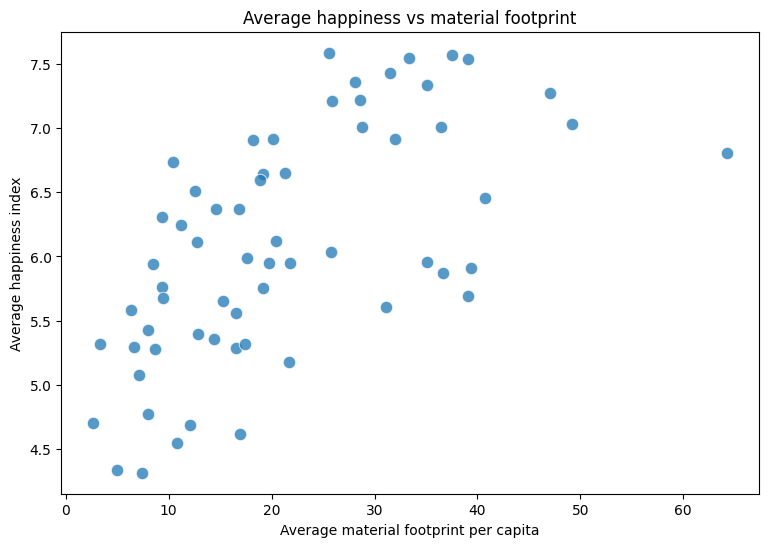

In [107]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=country_env_avg,
    x="material_footprint_per_capita",
    y="happiness_index",
    alpha=0.75,
    s=80,
)

plt.xlabel("Average material footprint per capita")
plt.ylabel("Average happiness index")

plt.title(
    "Average happiness vs material footprint"
)

plt.show()

## 11. Final synthesis: wellbeing, inequality, and material footprint

The previous analyses suggest that production-based and consumption-based CO₂ emissions exhibit highly similar relationships with wellbeing, while material footprint displays a somewhat different structure characterized by greater dispersion and stronger diminishing-return patterns at high levels of resource use.

For the final synthesis section, particular attention is therefore given to material footprint as a broad indicator of environmental and resource intensity.

Unlike CO₂ emissions alone, material footprint captures wider patterns of embodied resource extraction and consumption, including biomass, metals, fossil materials, and construction minerals. As a result, it may provide a more direct representation of the material throughput required to sustain different levels of wellbeing.

The earlier scatterplots also suggested that very high material-footprint levels are not associated with proportionally higher happiness outcomes, indicating possible diminishing wellbeing returns to increasingly resource-intensive forms of development.

This makes material footprint particularly relevant for examining questions related to wellbeing-efficiency, environmental decoupling, and the extent to which subjective wellbeing gains continue to scale with material consumption.

In [108]:
country_material_synthesis = (
    eda_df.groupby("country")[
        [
            "happiness_index",
            "inequality_adjusted_happiness",
            "material_footprint_per_capita",
            "gini_index",
        ]
    ]
    .mean()
    .reset_index()
)

In [109]:
countries_to_label = [
    "Brazil",
    "Colombia",
    "Mexico",
    "Denmark",
    "Switzerland",
    "United States",
    "Vietnam",
    "Sri Lanka",
]

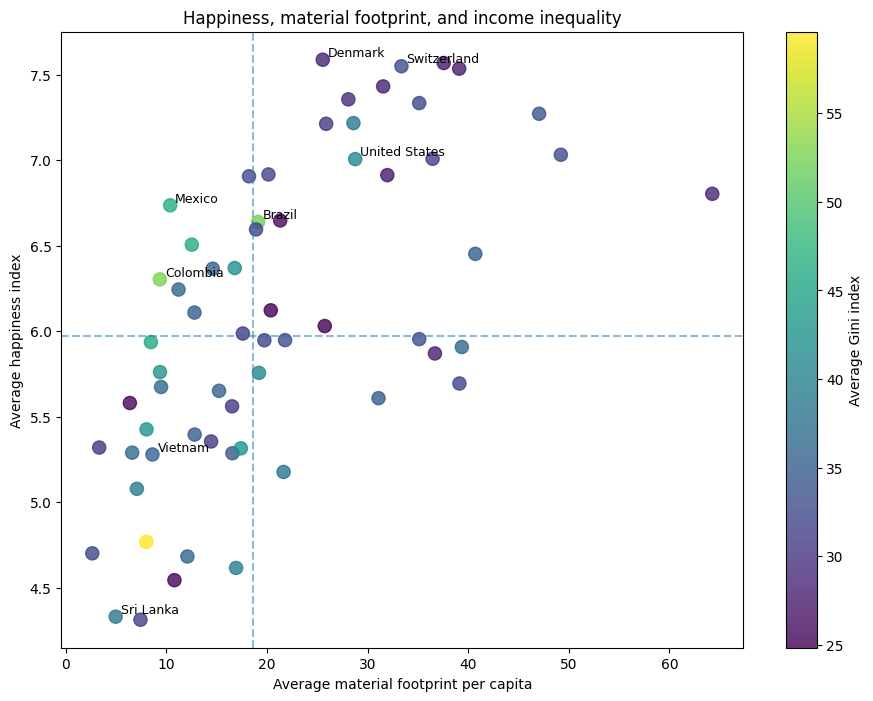

In [110]:
plt.figure(figsize=(11, 8))

scatter = plt.scatter(
    country_material_synthesis["material_footprint_per_capita"],
    country_material_synthesis["happiness_index"],
    c=country_material_synthesis["gini_index"],
    s=90,
    alpha=0.8,
)

plt.axhline(
    country_material_synthesis["happiness_index"].median(),
    linestyle="--",
    alpha=0.5,
)

plt.axvline(
    country_material_synthesis["material_footprint_per_capita"].median(),
    linestyle="--",
    alpha=0.5,
)

for _, row in country_material_synthesis.iterrows():
    if row["country"] in countries_to_label:
        plt.text(
            row["material_footprint_per_capita"] + 0.5,
            row["happiness_index"] + 0.02,
            row["country"],
            fontsize=9,
        )

plt.colorbar(
    scatter,
    label="Average Gini index",
)

plt.xlabel("Average material footprint per capita")
plt.ylabel("Average happiness index")

plt.title(
    "Happiness, material footprint, and income inequality"
)

plt.show()

The synthesis figure highlights several important tensions between wellbeing, environmental pressure, and inequality.

Countries with extremely high material footprints do not appear substantially happier than many countries with considerably lower levels of material consumption, reinforcing the earlier evidence of diminishing wellbeing returns to increasingly resource-intensive development patterns.

At the same time, the relationship between happiness and inequality appears more complex than a simple linear association. Extremely high inequality levels are rarely associated with very high happiness outcomes. However, several countries exhibiting moderate-to-high inequality nevertheless report comparatively high average happiness levels despite substantially lower material footprints than many highly developed economies.

This pattern suggests that subjective wellbeing does not map directly onto distributive equality alone. One possible interpretation is that subjective wellbeing measures partly reflect adaptation to prevailing social structures, expectations, and historically normalized inequalities. Under this interpretation, relatively high average happiness may coexist with substantial class differences and unequal access to resources, even if broader questions related to distributive justice or social cohesion remain unresolved.

The figure therefore reinforces the broader conclusion that very few countries appear to simultaneously combine high wellbeing, relatively low material-resource intensity, and low inequality.

## 12. Year-relative percentile comparisons

In [111]:
country_percentiles = (
    eda_df.groupby("country")[
        [
            "happiness_percentile_by_year",
            "material_footprint_percentile_by_year",
            "consumption_co2_percentile_by_year",
            "gini_index",
        ]
    ]
    .mean()
    .reset_index()
)

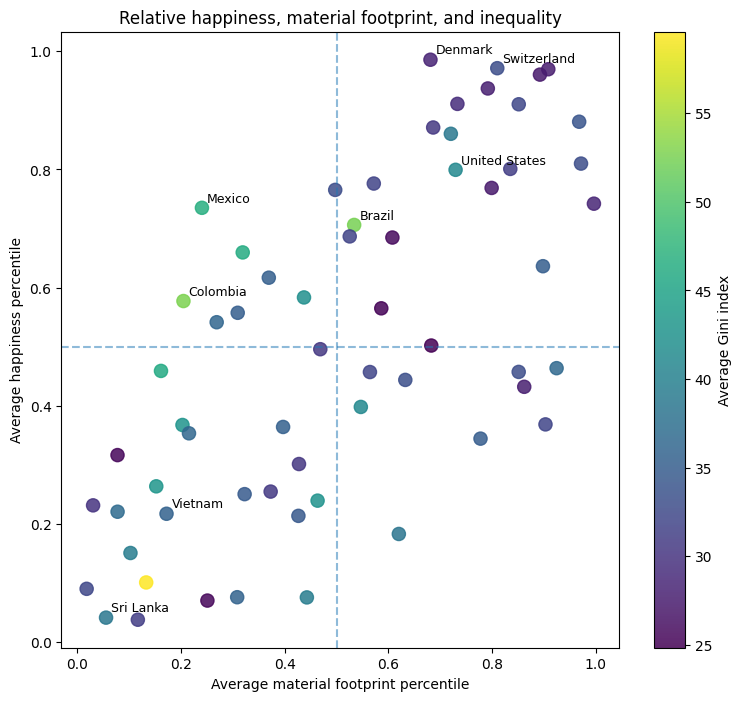

In [112]:
plt.figure(figsize=(9, 8))

scatter = plt.scatter(
    country_percentiles[
        "material_footprint_percentile_by_year"
    ],
    country_percentiles[
        "happiness_percentile_by_year"
    ],
    c=country_percentiles["gini_index"],
    alpha=0.85,
    s=90,
)

plt.axhline(0.5, linestyle="--", alpha=0.5)
plt.axvline(0.5, linestyle="--", alpha=0.5)

for country in [
    "Brazil",
    "Colombia",
    "Mexico",
    "Denmark",
    "Switzerland",
    "United States",
    "Vietnam",
    "Sri Lanka",
]:
    row = country_percentiles[
        country_percentiles["country"] == country
    ]

    if not row.empty:
        plt.text(
            row[
                "material_footprint_percentile_by_year"
            ].values[0] + 0.01,
            row[
                "happiness_percentile_by_year"
            ].values[0] + 0.01,
            country,
            fontsize=9,
        )

plt.colorbar(
    scatter,
    label="Average Gini index",
)

plt.xlabel(
    "Average material footprint percentile"
)

plt.ylabel(
    "Average happiness percentile"
)

plt.title(
    "Relative happiness, material footprint, and inequality"
)

plt.show()

The percentile synthesis figure highlights the broader structural trade-offs underlying the relationship between wellbeing, environmental intensity, and inequality.

Countries occupying the highest happiness percentiles are generally also associated with relatively high material-footprint percentiles, suggesting that very high subjective wellbeing outcomes frequently coexist with materially intensive development patterns. At the same time, countries such as Mexico, Brazil, and Colombia appear to achieve comparatively high happiness rankings despite substantially lower material-footprint positions than many highly developed economies, though often alongside comparatively higher levels of inequality.

Conversely, countries with very low material-footprint percentiles tend to remain concentrated in lower happiness percentiles, indicating that low material intensity alone does not necessarily translate into high subjective wellbeing outcomes.

Taken together, the figure suggests that few countries currently appear to simultaneously combine relatively high wellbeing, low material-resource intensity, and low inequality. The result reinforces the broader conclusion that relationships between wellbeing, sustainability, and distributive equity are characterised less by simple alignment than by persistent structural trade-offs.

In [113]:
fe_df = eda_df.copy()

fe_df["material_footprint_within_country"] = (
    fe_df["material_footprint_per_capita"]
    - fe_df.groupby("country")[
        "material_footprint_per_capita"
    ].transform("mean")
)

fe_df["happiness_within_country"] = (
    fe_df["happiness_index"]
    - fe_df.groupby("country")[
        "happiness_index"
    ].transform("mean")
)

fe_df["ineq_adj_happiness_within_country"] = (
    fe_df["inequality_adjusted_happiness"]
    - fe_df.groupby("country")[
        "inequality_adjusted_happiness"
    ].transform("mean")
)

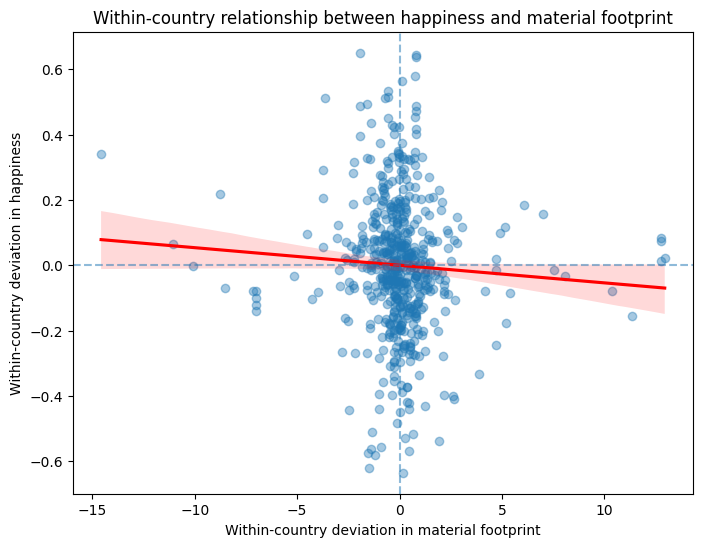

In [114]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=fe_df,
    x="material_footprint_within_country",
    y="happiness_within_country",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"},
)

plt.axhline(0, linestyle="--", alpha=0.5)
plt.axvline(0, linestyle="--", alpha=0.5)

plt.xlabel(
    "Within-country deviation in material footprint"
)

plt.ylabel(
    "Within-country deviation in happiness"
)

plt.title(
    "Within-country relationship between happiness and material footprint"
)

plt.show()

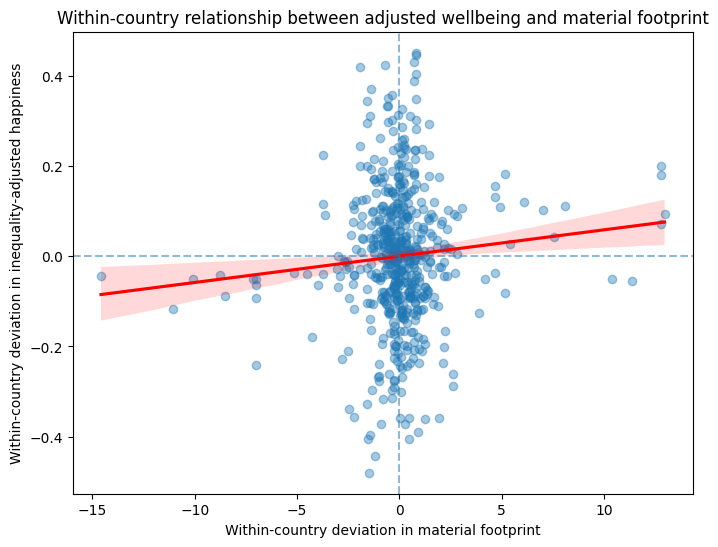

In [115]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=fe_df,
    x="material_footprint_within_country",
    y="ineq_adj_happiness_within_country",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"},
)

plt.axhline(0, linestyle="--", alpha=0.5)
plt.axvline(0, linestyle="--", alpha=0.5)

plt.xlabel(
    "Within-country deviation in material footprint"
)

plt.ylabel(
    "Within-country deviation in inequality-adjusted happiness"
)

plt.title(
    "Within-country relationship between adjusted wellbeing and material footprint"
)

plt.show()

The within-country relationship between happiness and the combined environmental-pressure index is extremely weak and appears approximately flat after removing country-specific average levels.

This contrasts sharply with the earlier pooled and country-average relationships, where countries with higher environmental pressure often also exhibited higher average happiness levels.

Once persistent structural differences between countries are removed, increases in environmental pressure within countries over time do not appear systematically associated with higher subjective wellbeing.

The result suggests that much of the observed cross-country relationship between wellbeing and environmental intensity may reflect broader developmental and structural differences rather than strong short-run wellbeing gains from increasing environmental-resource use itself.

The near-flat fitted relationship also reinforces the broader pattern observed throughout the notebook: beyond moderate levels of development, increasingly resource-intensive economic activity may generate limited additional subjective wellbeing returns.

### GDP-per-capita grouping

We next examine whether the within-country relationship between material footprint and happiness differs across countries at different levels of economic development.

To explore this, countries are divided into two groups based on median GDP per capita. This allows us to investigate whether increases in material-resource intensity are associated with different wellbeing dynamics in relatively richer and relatively poorer economies.

In [116]:
median_gdp_pc = (
    fe_df["gdp"] / fe_df["population"]
).median()

fe_df["gdp_group"] = np.where(
    (fe_df["gdp"] / fe_df["population"])
    >= median_gdp_pc,
    "Higher GDP per capita",
    "Lower GDP per capita",
)

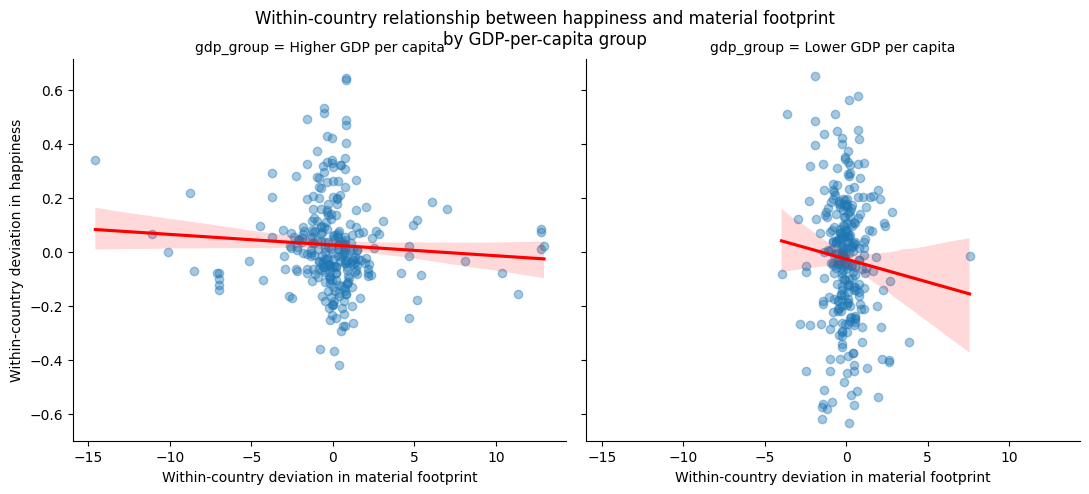

In [117]:
g = sns.lmplot(
    data=fe_df,
    x="material_footprint_within_country",
    y="happiness_within_country",
    col="gdp_group",
    height=5,
    aspect=1.1,
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"},
)

g.set_axis_labels(
    "Within-country deviation in material footprint",
    "Within-country deviation in happiness",
)

g.fig.subplots_adjust(top=0.88)

g.fig.suptitle(
    "Within-country relationship between happiness and material footprint\nby GDP-per-capita group"
)

plt.show()

The GDP-per-capita grouping suggests that within-country increases in material footprint are associated with weakly negative relationships with happiness in both groups, with the decline appearing somewhat steeper among lower-GDP-per-capita economies.

This pattern provides little evidence that increasing material-resource intensity systematically generates short-run subjective wellbeing improvements, even within relatively poorer economies. Instead, the results are more consistent with the broader saturation narrative developed throughout the analysis: additional material intensification alone does not appear sufficient to produce large or persistent gains in subjective wellbeing.

One possible interpretation is that increases in material consumption may not automatically diffuse into broadly experienced wellbeing improvements, particularly where gains remain unevenly distributed, economically volatile, or concentrated within specific sectors of the economy.

At the same time, the fitted relationships remain weak relative to the substantial dispersion in the data, and the confidence intervals overlap considerably. The results should therefore be interpreted cautiously and descriptively rather than causally.

### CO₂ trade-balance grouping

We now examine the same relationship by separating countries according to their CO₂ consumption-production gap.

This distinction captures whether countries are relatively more consumption/import-oriented or production/export-oriented in their emissions profile, allowing us to explore whether wellbeing dynamics differ depending on how environmental pressures are distributed within global production-consumption systems.

In [118]:
median_co2_gap = fe_df[
    "co2_consumption_production_gap"
].median()

fe_df["co2_gap_group"] = np.where(
    fe_df["co2_consumption_production_gap"]
    >= median_co2_gap,
    "Net consumption/import-oriented",
    "Net production/export-oriented",
)

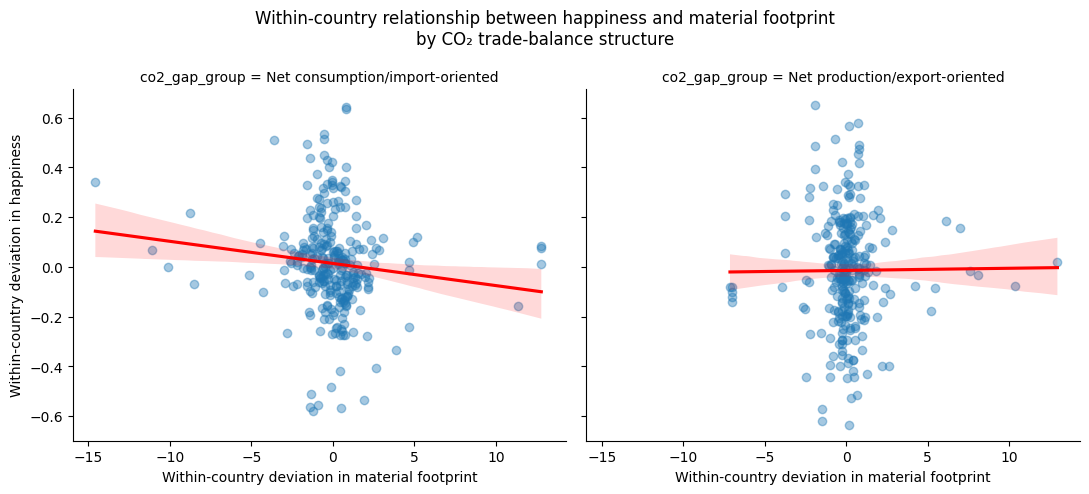

In [119]:
g = sns.lmplot(
    data=fe_df,
    x="material_footprint_within_country",
    y="happiness_within_country",
    col="co2_gap_group",
    height=5,
    aspect=1.1,
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"},
)

g.set_axis_labels(
    "Within-country deviation in material footprint",
    "Within-country deviation in happiness",
)

g.fig.subplots_adjust(top=0.82)

g.fig.suptitle(
    "Within-country relationship between happiness and material footprint\nby CO₂ trade-balance structure"
)

plt.show()

The CO₂ trade-balance grouping suggests that within-country increases in material footprint are associated with a weak negative relationship with happiness among net consumption/import-oriented economies, while the relationship appears approximately flat among net production/export-oriented economies.

This pattern is broadly consistent with the wider saturation narrative developed throughout the analysis: additional material intensification does not appear to systematically generate higher subjective wellbeing once countries are already embedded in relatively consumption-intensive development patterns.

At the same time, the effects remain weak overall and highly dispersed, indicating that material-resource intensity alone provides only limited explanatory power for short-run within-country changes in subjective wellbeing.

### Inequality-adjusted wellbeing comparison

Finally, we repeat the previous analyses using inequality-adjusted happiness instead of the raw happiness index.

This allows us to examine whether accounting for distributive inequality changes the apparent relationship between material-resource intensity and wellbeing dynamics.

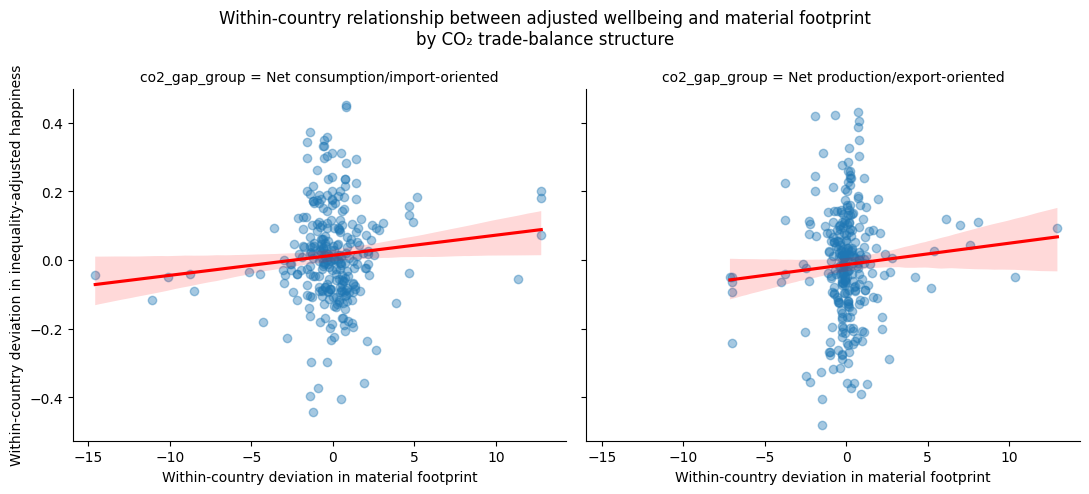

In [120]:
g = sns.lmplot(
    data=fe_df,
    x="material_footprint_within_country",
    y="ineq_adj_happiness_within_country",
    col="co2_gap_group",
    height=5,
    aspect=1.1,
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"},
)

g.set_axis_labels(
    "Within-country deviation in material footprint",
    "Within-country deviation in inequality-adjusted happiness",
)

g.fig.subplots_adjust(top=0.82)

g.fig.suptitle(
    "Within-country relationship between adjusted wellbeing and material footprint\nby CO₂ trade-balance structure"
)

plt.show()

The within-country analyses suggest that short-run increases in material footprint are associated with only limited changes in subjective wellbeing overall. In the unadjusted happiness models, the relationships remain weakly negative or approximately flat across most groupings, indicating little evidence that additional material intensification systematically produces substantial immediate wellbeing gains.

At the same time, the inequality-adjusted versions reveal weak positive relationships, particularly among net consumption/import-oriented economies. One possible interpretation is that increases in material consumption may partially buffer or temporarily compensate for some of the distributive tensions associated with unequal social structures, producing modest aggregate welfare gains that become more visible once inequality is explicitly accounted for.

Taken together, the results suggest an important distinction between short-run within-country dynamics and broader long-run structural patterns. While increases in material consumption may still generate limited local wellbeing improvements under some conditions, the earlier cross-country analyses showed that highly unequal and materially intensive development patterns remain associated with broader structural trade-offs and diminishing wellbeing returns over time.

This interpretation aligns with the broader narrative developed throughout the analysis: material intensification alone does not appear sufficient to sustainably overcome the deeper social and distributive constraints shaping collective wellbeing.

## 13. Main exploratory findings

## RQ1. To what extent are higher levels of subjective wellbeing associated with greater environmental and material intensity across countries?

The cross-country analyses revealed clear positive relationships between subjective wellbeing and both environmental and material intensity indicators, particularly consumption-based CO₂ emissions and material footprint per capita. Countries with higher average happiness levels generally also exhibited higher levels of resource use and environmental pressure.

However, the relationships displayed strong diminishing-return patterns. In particular, the material-footprint analyses showed that countries with extremely high levels of material consumption were not proportionally happier than many countries operating at substantially lower levels of resource intensity. This suggests that increasing environmental and material intensity may support wellbeing up to a point, after which additional gains become progressively smaller.

The findings therefore indicate that high wellbeing outcomes are frequently associated with materially intensive development patterns, while also suggesting that environmental intensification alone does not systematically translate into proportionally higher subjective wellbeing.



---

## RQ2. Are some countries able to achieve comparatively high wellbeing outcomes with lower environmental intensity?

Several countries appeared comparatively “wellbeing-efficient,” achieving relatively high happiness outcomes despite substantially lower environmental intensity than many highly developed economies.

This pattern emerged particularly clearly in the happiness-per-emissions and happiness-per-material-footprint comparisons, where countries such as Mexico, Brazil, Colombia, and Thailand frequently outperformed many materially intensive economies on relative wellbeing-efficiency metrics.

At the same time, these countries often exhibited comparatively higher levels of inequality, complicating straightforward interpretations of sustainable wellbeing performance. The results therefore suggest that relatively high subjective wellbeing can sometimes coexist with lower environmental intensity, but not necessarily alongside equitable distributive outcomes.

---

## RQ3. How does income inequality complicate the relationship between wellbeing and environmental sustainability?

The percentile synthesis analyses highlighted inequality as a central complicating dimension in the relationship between wellbeing and sustainability.

Countries occupying the highest happiness percentiles were generally also associated with high material-footprint percentiles, reinforcing the strong structural connection between wellbeing and material intensity. However, the addition of inequality revealed a more nuanced picture. Some countries achieved comparatively high subjective wellbeing despite moderate-to-high inequality levels and substantially lower material footprints than highly developed economies.

This pattern suggests that subjective wellbeing may partly reflect adaptation to prevailing social and economic structures, including historically normalised inequalities and unequal access to opportunities. Under this interpretation, relatively high average happiness may coexist with substantial distributive inequality even where broader questions related to social cohesion or distributive justice remain unresolved.

More broadly, the synthesis figures revealed a persistent structural gap: very few countries appeared to simultaneously combine high wellbeing, low material-resource intensity, and low inequality.

---

## RQ4. Do short-run within-country increases in material intensity translate into consistent wellbeing improvements?

The within-country analyses suggested that short-run increases in material footprint were associated with only weak and highly variable changes in wellbeing overall.

When using the raw happiness index, the relationships remained approximately flat or weakly negative across most groupings, particularly among net consumption/import-oriented economies. This is consistent with the broader saturation narrative observed throughout the analysis: additional material intensification does not appear to systematically generate substantial subjective wellbeing gains once countries are already embedded in materially intensive development structures.

However, when happiness was adjusted for inequality, the relationships became weakly positive. One possible interpretation is that increases in material consumption may temporarily buffer or partially compensate for some of the distributive tensions associated with unequal social structures, producing modest aggregate welfare gains that become more visible once inequality is explicitly accounted for.

Taken together, these results suggest an important distinction between short-run local dynamics and broader long-run structural patterns. While material intensification may still generate limited local wellbeing improvements under some conditions, the broader cross-country analyses indicate that increasingly resource-intensive development patterns remain associated with diminishing returns, inequality-related tensions, and persistent structural trade-offs.

---

## Overall synthesis

Taken together, the analyses suggest that the relationship between wellbeing, environmental sustainability, and inequality is characterised less by simple alignment than by persistent structural tensions and diminishing returns.

High levels of wellbeing are frequently associated with materially intensive forms of development, yet extremely high levels of environmental pressure do not appear to produce proportionally higher wellbeing outcomes. At the same time, countries achieving comparatively efficient wellbeing outcomes often continue to exhibit substantial inequality, while countries with low environmental intensity alone do not necessarily achieve high wellbeing outcomes.

The findings therefore suggest that evaluating national progress through a multidimensional framework incorporating wellbeing, environmental sustainability, and distributive equity may provide a richer perspective than relying on any single indicator in isolation.

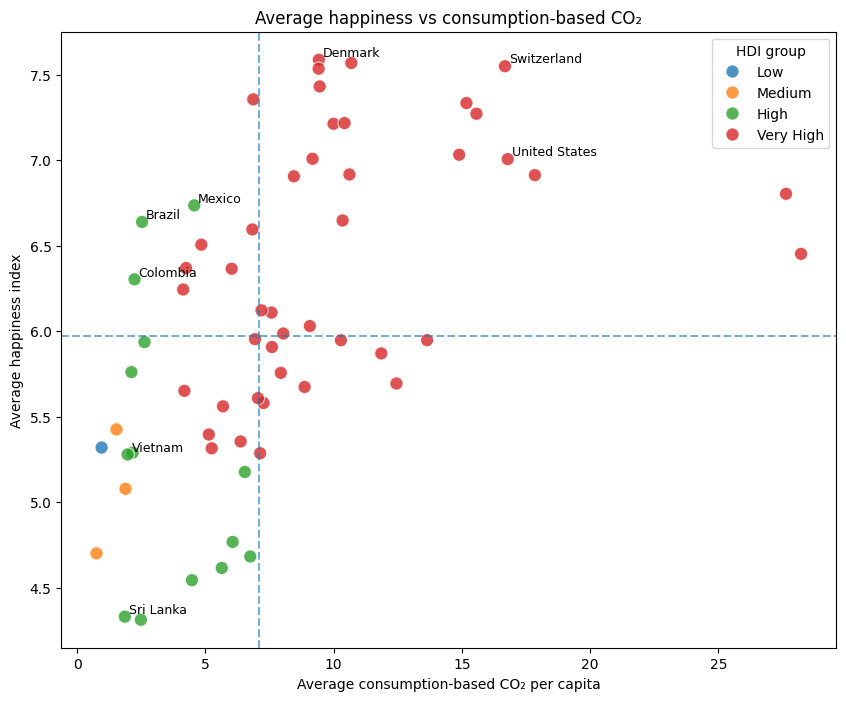

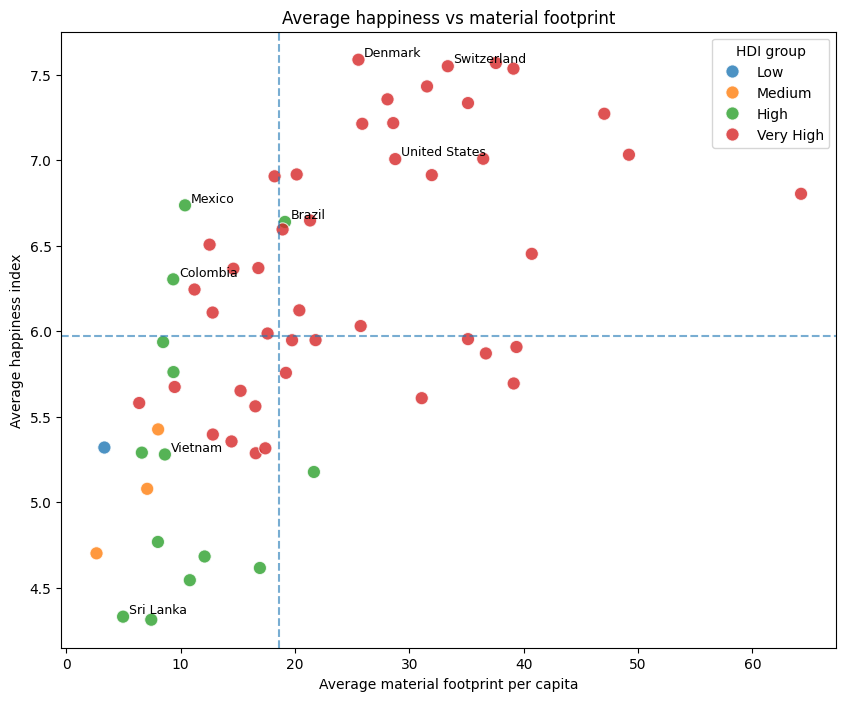

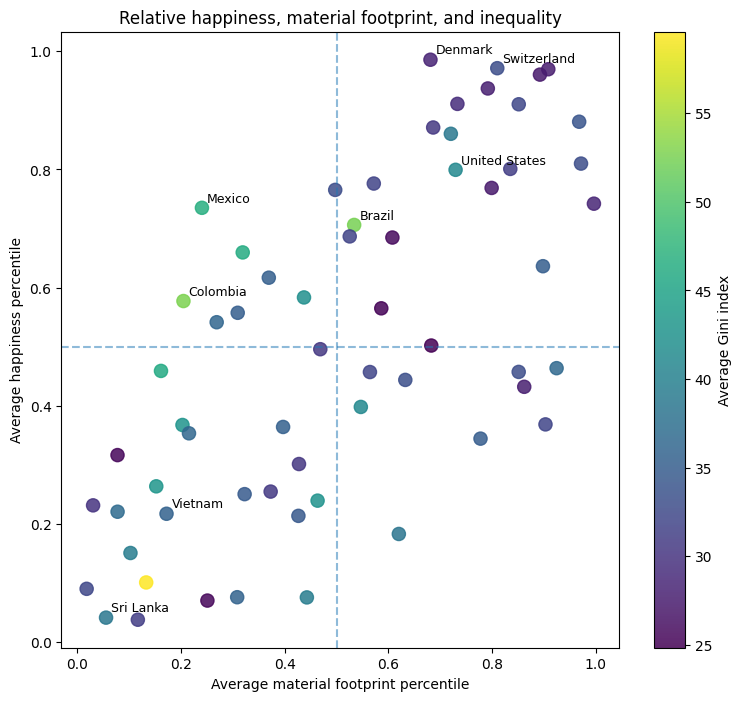

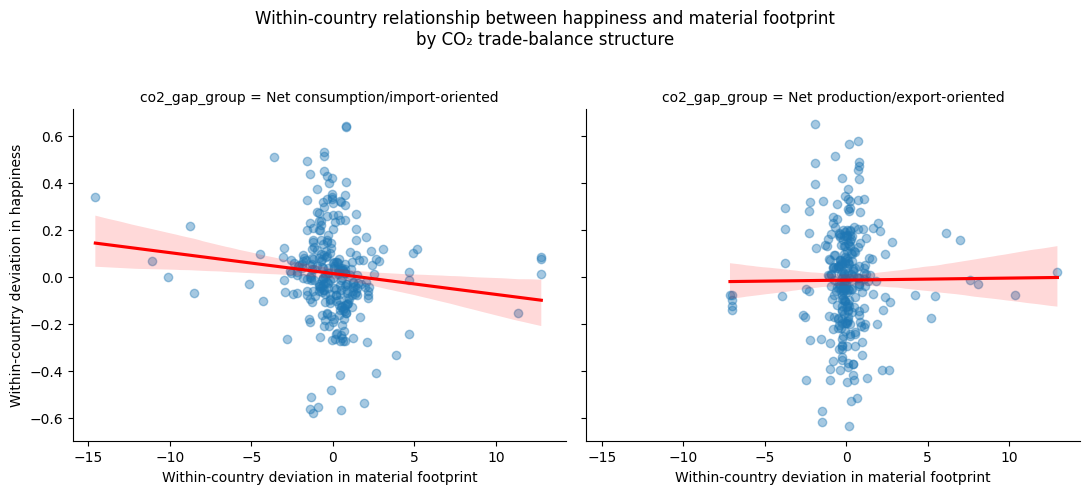

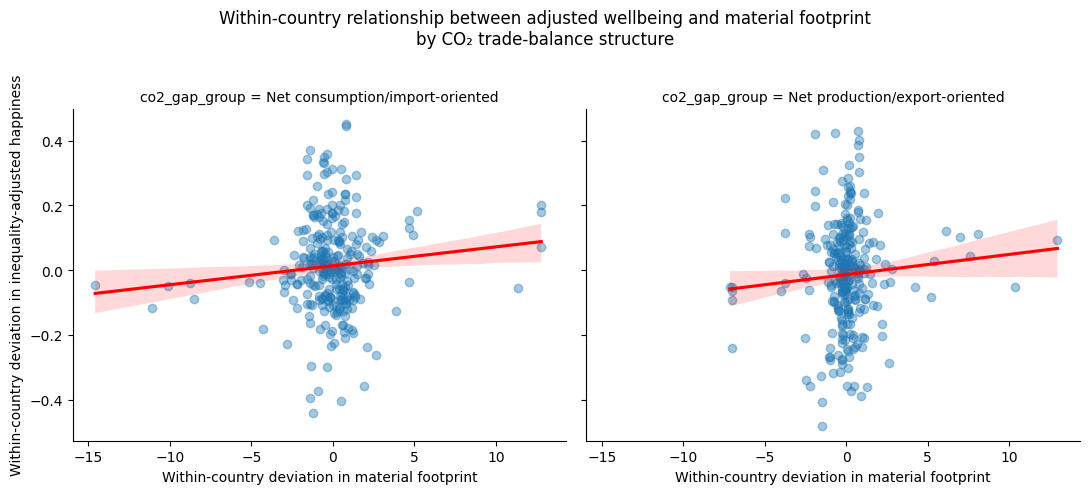

In [121]:
plot_main_exploratory_findings(eda_df)